In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
df = pd.read_excel("Kompilasi Data 2.xlsx")

In [56]:
df.shape

(38, 14)

In [57]:
df.head()

,Provinsi,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital,Makanan Per Kapita,Non Makanan Per Kapita,Persentase Penduduk Miskin - September
0,Aceh,74.03,98.864334,50.50,37.65,108507,5086801,75.99,5.12,198.69,0.99,722434.000793,542298.945247,12.64
1,Sumatera Utara,74.02,96.613774,49.05,35.38,123911,7957689,73.15,2.72,172.37,4.06,734270.163893,606687.150529,7.19
2,Sumatera Barat,74.49,98.055988,47.62,28.75,88053,4567033,75.14,5.56,194.63,3.08,797727.891800,683125.287664,5.42
3,Riau,74.79,98.395722,47.42,36.93,54425,3494581,82.49,2.57,156.56,5.66,824229.254186,738936.225119,6.36
4,Jambi,73.43,98.296530,47.10,33.90,31268,2065021,85.91,3.65,150.80,4.12,773667.406594,698833.345724,7.26


In [58]:
df.tail()

,Provinsi,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital,Makanan Per Kapita,Non Makanan Per Kapita,Persentase Penduduk Miskin - September
33,Papua Barat Daya,68.63,92.329545,40.46,24.68,2861,272521,74.43,5.26,156.89,2.57,8.108626e+05,831867.441055,16.95
34,Papua,73.00,88.046647,40.11,23.29,7499,398165,74.11,7.02,172.14,11.27,7.653928e+05,813501.051315,18.09
35,Papua Selatan,67.90,84.782609,38.32,28.98,4931,363652,73.21,2.91,236.01,1.29,7.494745e+05,677615.678251,19.35
36,Papua Tengah,59.75,27.897351,36.66,28.78,3828,290986,73.28,0.56,156.26,1.75,8.870392e+05,600648.738014,27.60
37,Papua Pegunungan,53.42,36.712225,32.48,2.70,587,51030,57.30,2.89,151.42,0.00,1.157571e+06,570904.333183,29.66


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 14 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Provinsi                                38 non-null     str    
 1   IPM                                     38 non-null     float64
 2   Infrastruktur_Desa                      38 non-null     float64
 3   IMDI                                    38 non-null     float64
 4   Persen_Ecommerce                        38 non-null     float64
 5   Jumlah_UMKM                             38 non-null     int64  
 6   nilai_tambah                            38 non-null     int64  
 7   Penetrasi_Internet                      38 non-null     float64
 8   Pelatihan_TIK                           38 non-null     float64
 9   Level_TIK                               38 non-null     float64
 10  Pembayaran_Digital                      38 non-null     float64
 11  Makana

In [60]:
#finding missing value
df.isnull().sum()

Provinsi                                  0
IPM                                       0
Infrastruktur_Desa                        0
IMDI                                      0
Persen_Ecommerce                          0
Jumlah_UMKM                               0
nilai_tambah                              0
Penetrasi_Internet                        0
Pelatihan_TIK                             0
Level_TIK                                 0
Pembayaran_Digital                        0
Makanan Per Kapita                        0
Non Makanan Per Kapita                    0
Persentase Penduduk Miskin - September    0
dtype: int64

In [61]:
df.isnull().sum()/df.shape[0]*100

Provinsi                                  0.0
IPM                                       0.0
Infrastruktur_Desa                        0.0
IMDI                                      0.0
Persen_Ecommerce                          0.0
Jumlah_UMKM                               0.0
nilai_tambah                              0.0
Penetrasi_Internet                        0.0
Pelatihan_TIK                             0.0
Level_TIK                                 0.0
Pembayaran_Digital                        0.0
Makanan Per Kapita                        0.0
Non Makanan Per Kapita                    0.0
Persentase Penduduk Miskin - September    0.0
dtype: float64

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
#identify garbage value (ngecek kemungkinan adanya typo atau rare nilai yg tidak sesuai dgn konsep data)
for col in df.select_dtypes(include="object").columns:
    print(f"\nColumn: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print("Top values:")
    print(df[col].value_counts().head(10))
    print("Rare values:")
    print(df[col].value_counts()[df[col].value_counts() <= 2].head(20))
    print("-" * 50)


Column: Provinsi
Unique values: 38
Top values:
Provinsi
Aceh                    1
Sumatera Utara          1
Sumatera Barat          1
Riau                    1
Jambi                   1
Sumatera Selatan        1
Bengkulu                1
Lampung                 1
Kep. Bangka Belitung    1
Kepulauan Riau          1
Name: count, dtype: int64
Rare values:
Provinsi
Aceh                    1
Sumatera Utara          1
Sumatera Barat          1
Riau                    1
Jambi                   1
Sumatera Selatan        1
Bengkulu                1
Lampung                 1
Kep. Bangka Belitung    1
Kepulauan Riau          1
DKI Jakarta             1
Jawa Barat              1
Jawa Tengah             1
D.I. Yogyakarta         1
Jawa Timur              1
Banten                  1
Bali                    1
Nusa Tenggara Barat     1
Nusa Tenggara Timur     1
Kalimantan Barat        1
Name: count, dtype: int64
--------------------------------------------------


C:\Users\DINDA\AppData\Local\Temp\ipykernel_17648\2455383290.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [64]:
df.describe(include="object")

C:\Users\DINDA\AppData\Local\Temp\ipykernel_17648\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Provinsi
count,38
unique,38
top,Aceh
freq,1


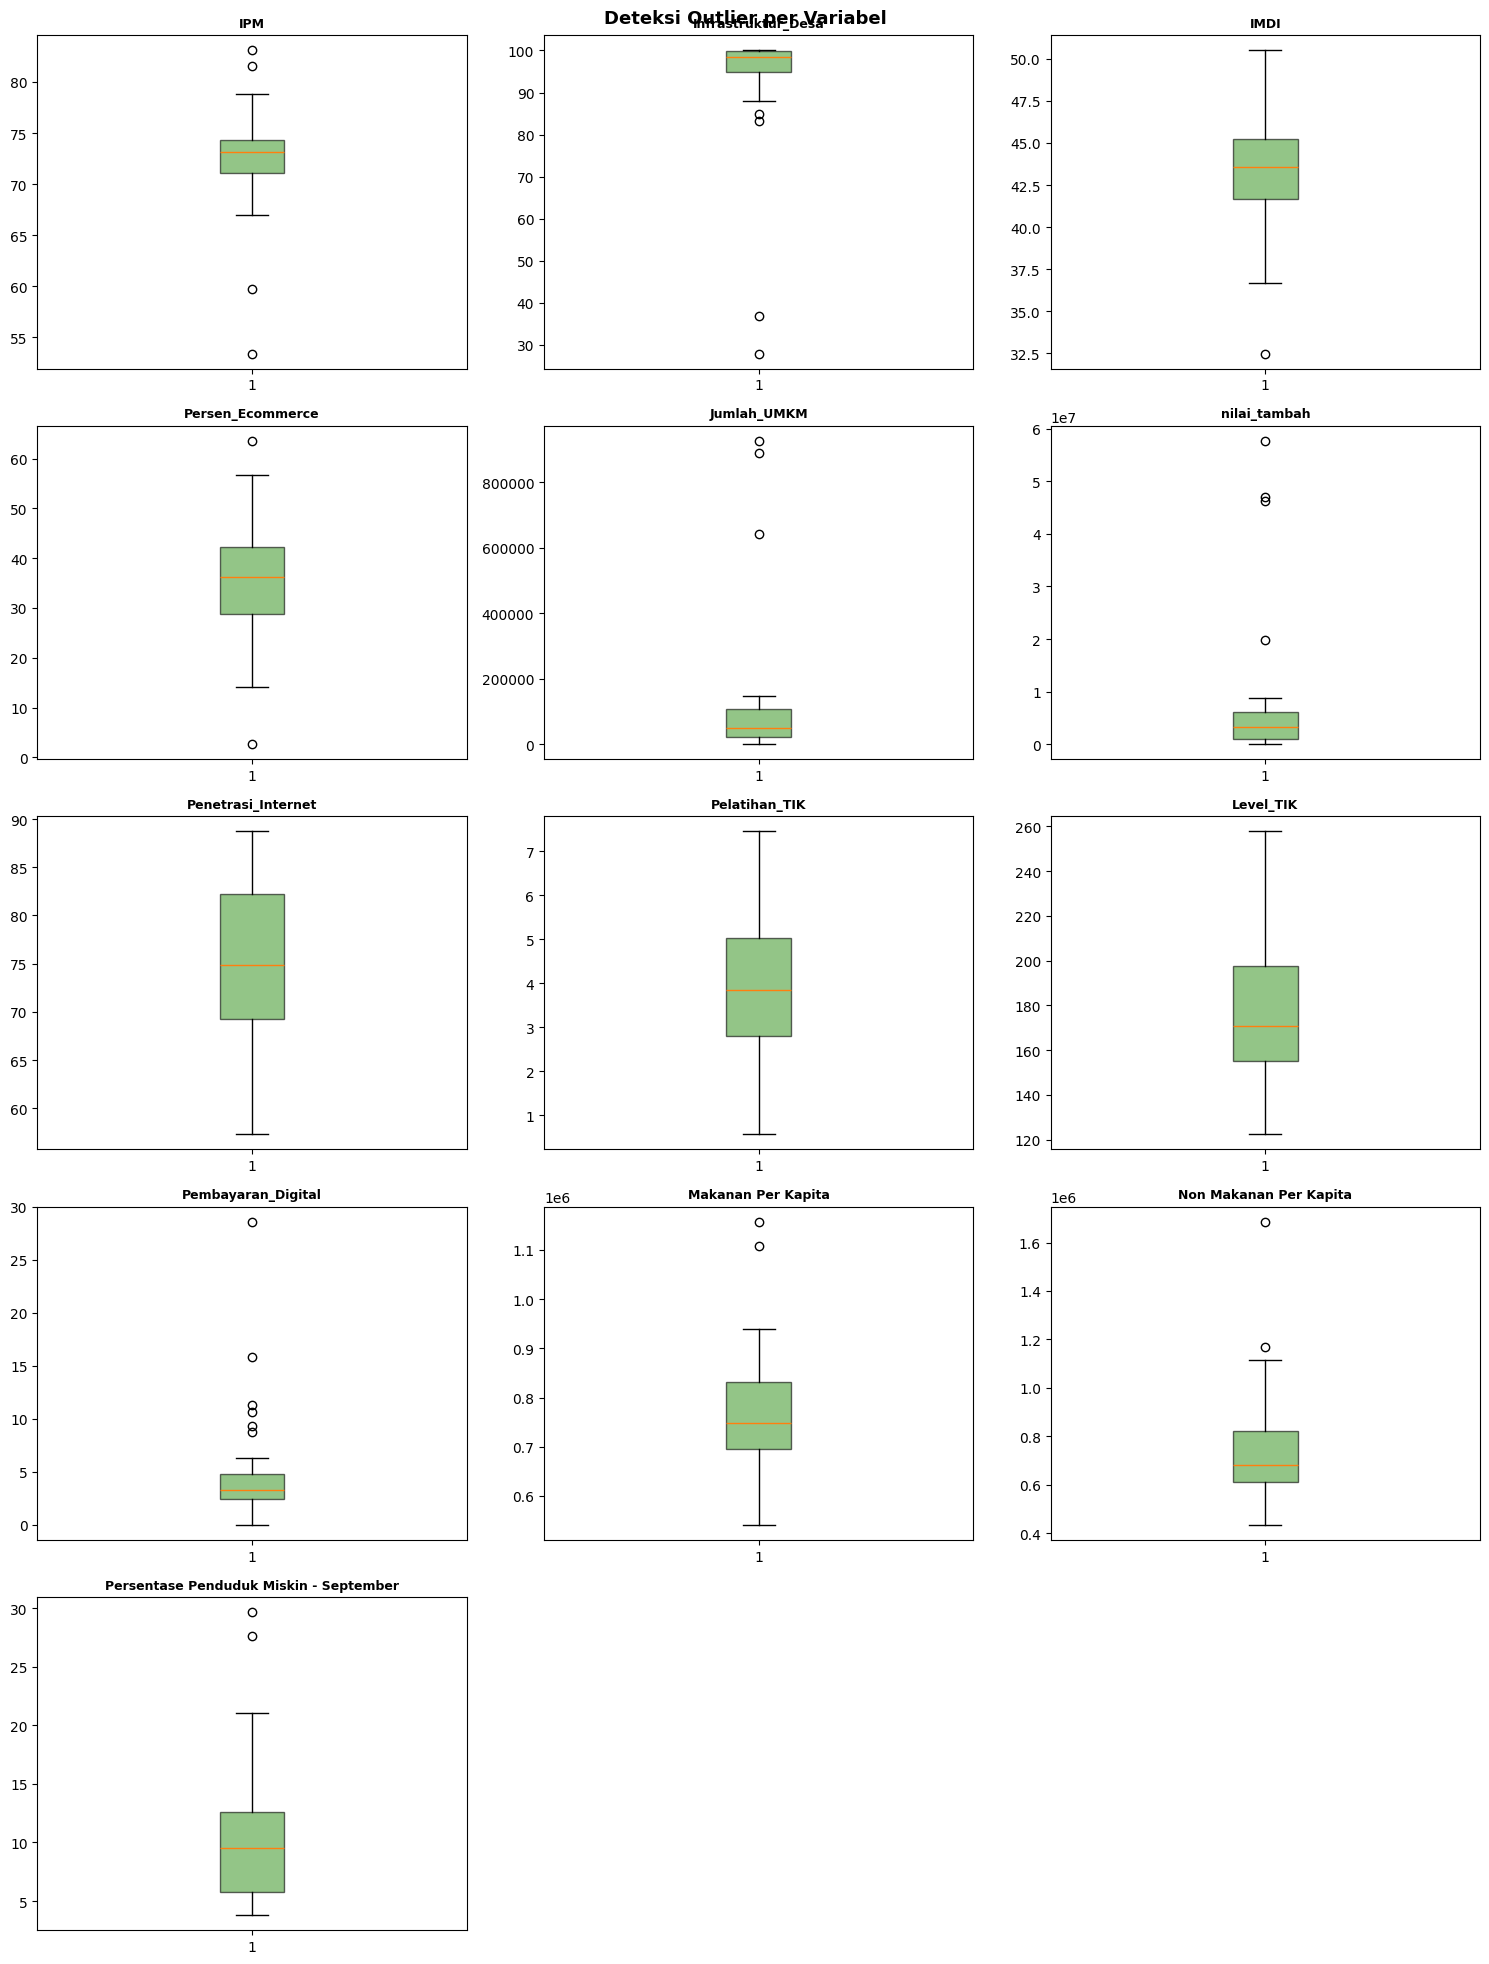

In [65]:
#deteksi outlier dengan boxplot
df_num = df.drop(columns=['Provinsi'])

cols = df_num.columns
n_cols = 3
n_rows = -(-len(cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df_num[col], patch_artist=True,
                    boxprops=dict(facecolor='#4C9F38', alpha=0.6))
    axes[i].set_title(col, fontsize=9, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier per Variabel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pengecilan skala, (jumlah umkm dan nilai tamnbah)

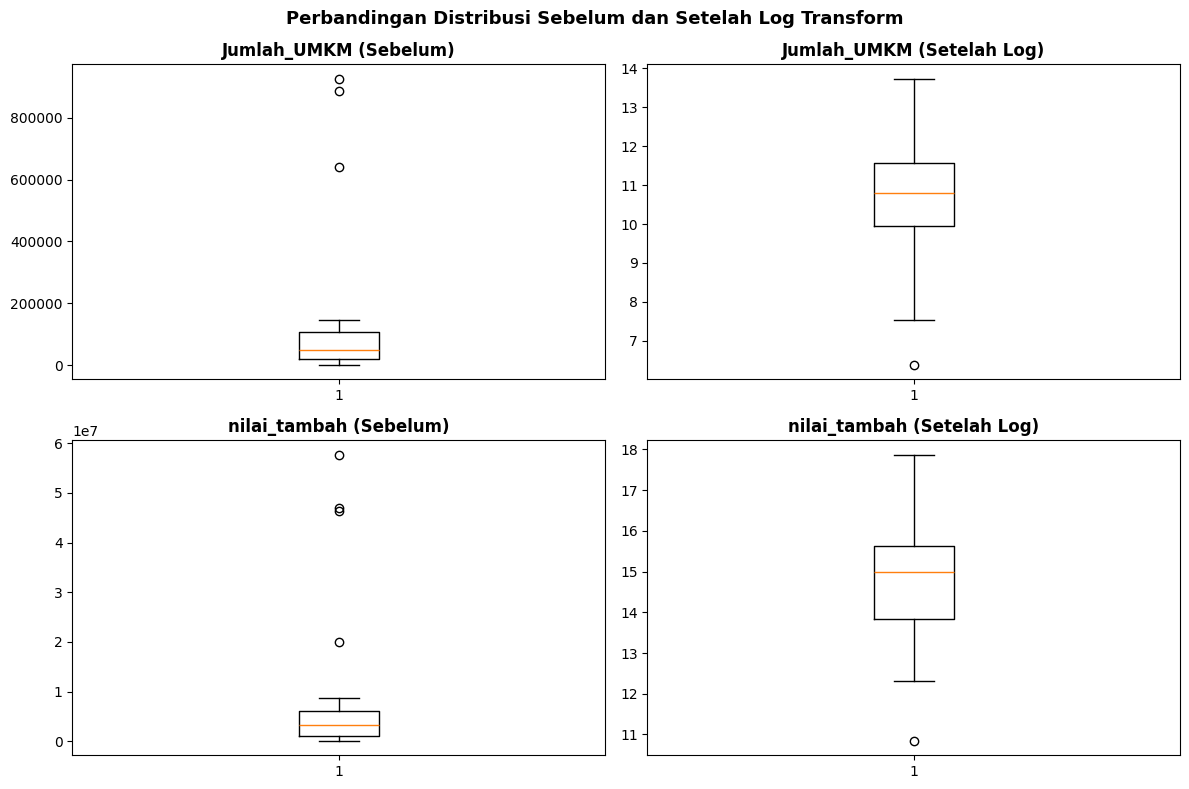


Sebelum Log Transform:
       Jumlah_UMKM  nilai_tambah
count       38.000  3.800000e+01
mean    116143.289  7.301559e+06
std     215817.568  1.336654e+07
min        587.000  5.103000e+04
25%      20746.750  1.024709e+06
50%      49199.000  3.203949e+06
75%     106311.750  6.088314e+06
max     925985.000  5.769454e+07

Setelah Log Transform:
       Jumlah_UMKM  nilai_tambah
count       38.000        38.000
mean        10.610        14.728
std          1.591         1.553
min          6.377        10.840
25%          9.940        13.840
50%         10.804        14.979
75%         11.573        15.622
max         13.739        17.871


In [66]:
# Log Transformation untuk variabel dengan outlier ekstrem
df_log = df.copy()
df_log['Jumlah_UMKM'] = np.log1p(df['Jumlah_UMKM'])
df_log['nilai_tambah'] = np.log1p(df['nilai_tambah'])

# Visualisasi perbandingan
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].boxplot(df['Jumlah_UMKM'])
axes[0,0].set_title('Jumlah_UMKM (Sebelum)', fontweight='bold')

axes[0,1].boxplot(df_log['Jumlah_UMKM'])
axes[0,1].set_title('Jumlah_UMKM (Setelah Log)', fontweight='bold')

axes[1,0].boxplot(df['nilai_tambah'])
axes[1,0].set_title('nilai_tambah (Sebelum)', fontweight='bold')

axes[1,1].boxplot(df_log['nilai_tambah'])
axes[1,1].set_title('nilai_tambah (Setelah Log)', fontweight='bold')

plt.suptitle('Perbandingan Distribusi Sebelum dan Setelah Log Transform',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSebelum Log Transform:")
print(df[['Jumlah_UMKM', 'nilai_tambah']].describe().round(3))
print("\nSetelah Log Transform:")
print(df_log[['Jumlah_UMKM', 'nilai_tambah']].describe().round(3))

outlier ekstrim di : 
Jumlah_UMKM, nilai_tambah, Pelatihan_TIK, Infrastruktur_Desa

In [67]:
#normalisasi data, using minmax and standard scaler

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Pisahkan kolom provinsi
provinsi = df_log['Provinsi']
df_num = df_log.drop(columns=['Provinsi'])

# Standard Scaler
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_num),
    columns=df_num.columns
)
df_standard.insert(0, 'Provinsi', provinsi.values)

print("Standard Scaler:")
print(df_standard.describe().round(3))

X = df_standard.drop(columns=['Provinsi']).values

Standard Scaler:
          IPM  Infrastruktur_Desa    IMDI  Persen_Ecommerce  Jumlah_UMKM  \
count  38.000              38.000  38.000            38.000       38.000   
mean   -0.000               0.000   0.000            -0.000       -0.000   
std     1.013               1.013   1.013             1.013        1.013   
min    -3.732              -4.351  -3.297            -2.746       -2.696   
25%    -0.257               0.105  -0.511            -0.544       -0.427   
50%     0.156               0.335   0.072             0.081        0.123   
75%     0.385               0.436   0.576             0.594        0.613   
max     2.104               0.445   2.172             2.395        1.992   

       nilai_tambah  Penetrasi_Internet  Pelatihan_TIK  Level_TIK  \
count        38.000              38.000         38.000     38.000   
mean          0.000              -0.000          0.000     -0.000   
std           1.013               1.013          1.013      1.013   
min          -2.538   

In [68]:
# MinMax Scaler
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_num),
    columns=df_num.columns
)
df_minmax.insert(0, 'Provinsi', provinsi.values)

print("MinMax Scaler:")
print(df_minmax.describe().round(3))

MinMax Scaler:
          IPM  Infrastruktur_Desa    IMDI  Persen_Ecommerce  Jumlah_UMKM  \
count  38.000              38.000  38.000            38.000       38.000   
mean    0.640               0.907   0.603             0.534        0.575   
std     0.174               0.211   0.185             0.197        0.216   
min     0.000               0.000   0.000             0.000        0.000   
25%     0.595               0.929   0.509             0.428        0.484   
50%     0.666               0.977   0.616             0.550        0.601   
75%     0.705               0.998   0.708             0.650        0.706   
max     1.000               1.000   1.000             1.000        1.000   

       nilai_tambah  Penetrasi_Internet  Pelatihan_TIK  Level_TIK  \
count        38.000              38.000         38.000     38.000   
mean          0.553               0.571          0.491      0.411   
std           0.221               0.266          0.213      0.249   
min           0.000     

komparasi minmax da standard

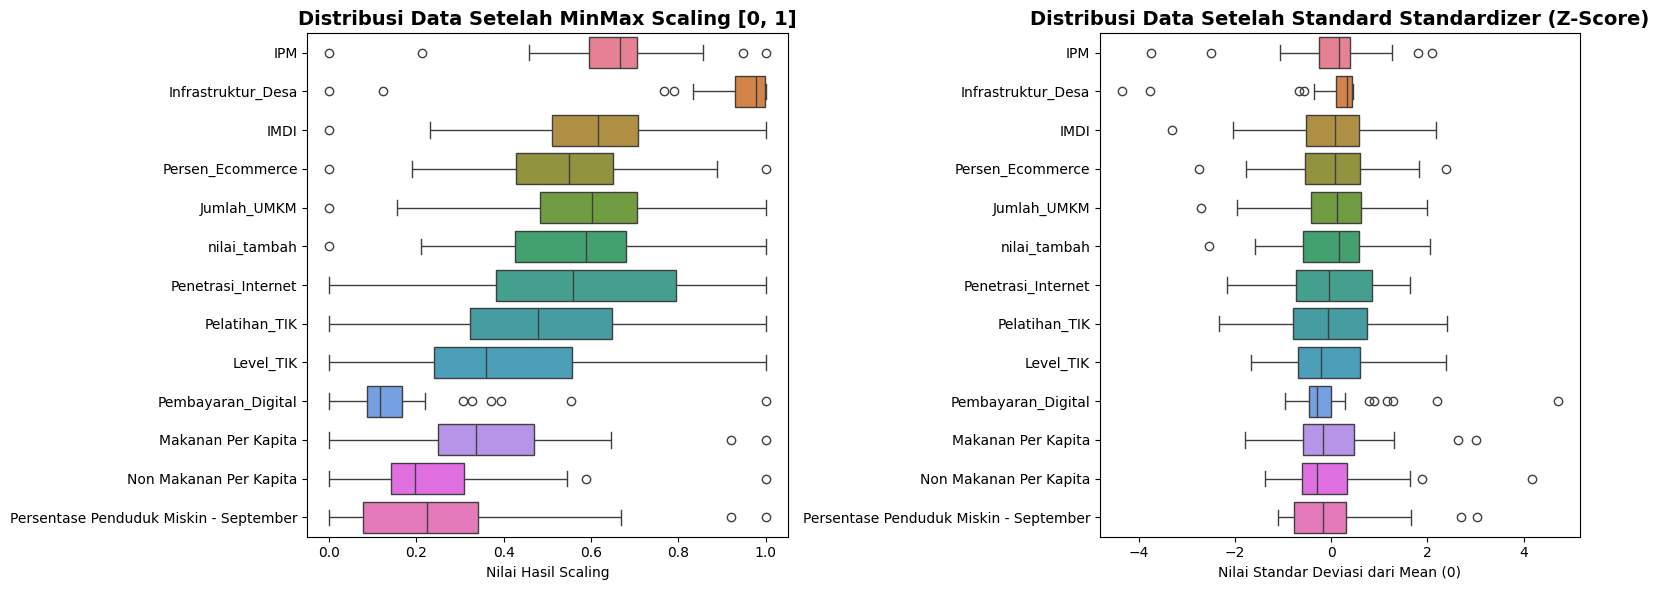

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_minmax.drop(columns=['Provinsi']), ax=axes[0], orient='h')
axes[0].set_title('Distribusi Data Setelah MinMax Scaling [0, 1]', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nilai Hasil Scaling')

sns.boxplot(data=df_standard.drop(columns=['Provinsi']), ax=axes[1], orient='h')
axes[1].set_title('Distribusi Data Setelah Standard Standardizer (Z-Score)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nilai Standar Deviasi dari Mean (0)')

plt.tight_layout()
plt.show()

In [70]:
df_num = df.drop(columns=['Provinsi'])

komparasi = pd.DataFrame(index=df_num.columns)

komparasi['MinMax_Min'] = df_minmax.drop(columns=['Provinsi']).min().round(3)
komparasi['MinMax_Mean'] = df_minmax.drop(columns=['Provinsi']).mean().round(3)
komparasi['MinMax_Max'] = df_minmax.drop(columns=['Provinsi']).max().round(3)

komparasi['StdScaler_Min'] = df_standard.drop(columns=['Provinsi']).min().round(3)
komparasi['StdScaler_Mean'] = df_standard.drop(columns=['Provinsi']).mean().round(3)
komparasi['StdScaler_Max'] = df_standard.drop(columns=['Provinsi']).max().round(3)

print("Tabel Komparasi")
komparasi

Tabel Komparasi


,MinMax_Min,MinMax_Mean,MinMax_Max,StdScaler_Min,StdScaler_Mean,StdScaler_Max
IPM,0.0,0.640,1.0,-3.732,-0.0,2.104
Infrastruktur_Desa,0.0,0.907,1.0,-4.351,0.0,0.445
IMDI,0.0,0.603,1.0,-3.297,0.0,2.172
Persen_Ecommerce,0.0,0.534,1.0,-2.746,-0.0,2.395
Jumlah_UMKM,0.0,0.575,1.0,-2.696,-0.0,1.992
nilai_tambah,0.0,0.553,1.0,-2.538,0.0,2.051
Penetrasi_Internet,0.0,0.571,1.0,-2.171,-0.0,1.634
Pelatihan_TIK,0.0,0.491,1.0,-2.337,0.0,2.419
Level_TIK,0.0,0.411,1.0,-1.674,-0.0,2.398
Pembayaran_Digital,0.0,0.168,1.0,-0.950,0.0,4.719


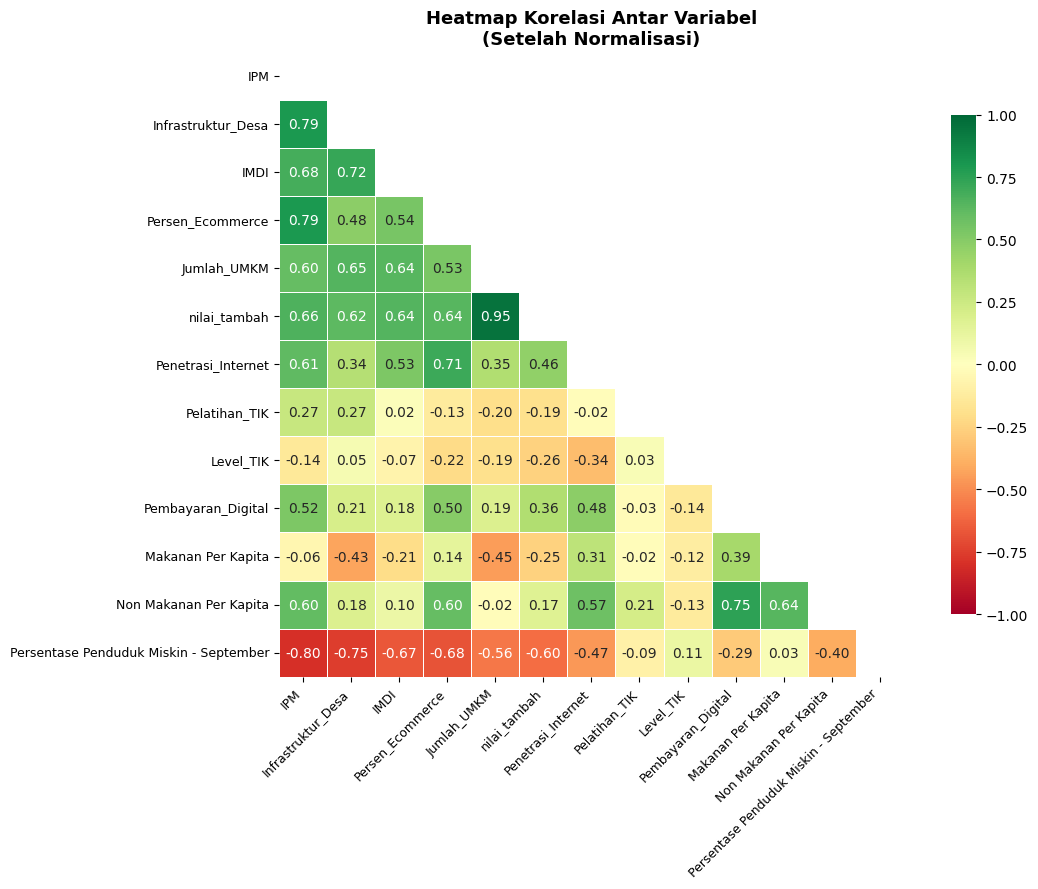


Pasangan variabel dengan korelasi > 0.85:
  Jumlah_UMKM & nilai_tambah: r = 0.952


In [71]:
corr = df_standard.drop(columns=['Provinsi']).corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Heatmap Korelasi Antar Variabel\n(Setelah Normalisasi)',
        fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Tampilkan pasangan korelasi tinggi
print("\nPasangan variabel dengan korelasi > 0.85:")
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.85:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i,j], 3)))

if high_corr:
    for h in high_corr:
        print(f"  {h[0]} & {h[1]}: r = {h[2]}")
else:
    print("  Tidak ada ✅")

In [72]:
import hdbscan
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from itertools import product

HBDSCAN dan GMM versi tanpa PCA

In [73]:
from itertools import product
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Siapkan data tanpa PCA
X = df_standard.drop(columns=['Provinsi']).values

best_score = -1
best_params = {}
results = []

for min_cluster, min_samp in product(range(2, 8), range(1, 6)):
    hdb_test = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster,
        min_samples=min_samp
    )
    labels = hdb_test.fit_predict(X)
    mask = labels != -1

    n_clusters = len(set(labels[mask]))
    n_noise = list(labels).count(-1)

    if n_clusters > 1 and sum(mask) > n_clusters:
        sil = silhouette_score(X[mask], labels[mask])
        dbi = davies_bouldin_score(X[mask], labels[mask])
        ch  = calinski_harabasz_score(X[mask], labels[mask])

        results.append({
            'min_cluster_size': min_cluster,
            'min_samples'     : min_samp,
            'n_clusters'      : n_clusters,
            'n_noise'         : n_noise,
            'silhouette'      : round(sil, 3),
            'dbi'             : round(dbi, 3),
            'calinski_harabasz': round(ch, 3)
        })

        if sil > best_score:
            best_score = sil
            best_params = {
                'min_cluster_size': min_cluster,
                'min_samples'     : min_samp
            }

df_tuning = pd.DataFrame(results).sort_values('silhouette', ascending=False)
print("Top 10 kombinasi parameter terbaik:")
print(df_tuning.head(10).to_string(index=False))
print(f"\n✅ Parameter terbaik: {best_params}")
print(f"   Silhouette Score     : {best_score:.3f}")

Top 10 kombinasi parameter terbaik:
 min_cluster_size  min_samples  n_clusters  n_noise  silhouette   dbi  calinski_harabasz
                2            1           2        1       0.542 0.622             14.885
                3            3           2       31       0.375 0.846              6.791
                2            4           2       23       0.268 0.973              4.276
                2            2           2       16       0.249 0.987              5.737
                3            2           2       16       0.249 0.987              5.737
                3            1           3       12       0.222 1.003              6.203
                4            2           2       28       0.202 1.409              3.774
                4            1           2       22       0.182 1.653              4.890
                6            1           2       22       0.182 1.653              4.890
                5            1           2       22       0.182 1.653     

EVALUASI HBDSCAN

In [74]:
# HDBSCAN Final dengan parameter terbaik
hdb_final = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=2)
labels_hdb_final = hdb_final.fit_predict(X)

df_hasil_hdb = df.copy()
df_hasil_hdb['Cluster_HDBSCAN'] = labels_hdb_final

# Evaluasi
mask_hdb = labels_hdb_final != -1
sil_hdb = silhouette_score(X[mask_hdb], labels_hdb_final[mask_hdb])
dbi_hdb = davies_bouldin_score(X[mask_hdb], labels_hdb_final[mask_hdb])
ch_hdb  = calinski_harabasz_score(X[mask_hdb], labels_hdb_final[mask_hdb])

print("=== HDBSCAN Final ===")
print(f"Jumlah klaster : {len(set(labels_hdb_final)) - (1 if -1 in labels_hdb_final else 0)}")
print(f"Noise points   : {list(labels_hdb_final).count(-1)}")
print(f"Distribusi     :\n{pd.Series(labels_hdb_final).value_counts().sort_index()}")
print(f"\nSilhouette Score      : {sil_hdb:.4f}")
print(f"Davies-Bouldin Index  : {dbi_hdb:.4f}")
print(f"Calinski-Harabasz     : {ch_hdb:.4f}")

# Cek isi tiap klaster
print("=== Isi Klaster HDBSCAN ===")
for cluster in sorted(df_hasil_hdb['Cluster_HDBSCAN'].unique()):
    provinsi_list = df_hasil_hdb[df_hasil_hdb['Cluster_HDBSCAN'] == cluster]['Provinsi'].tolist()
    label = "NOISE" if cluster == -1 else f"Klaster {cluster}"
    print(f"\n{label} ({len(provinsi_list)} provinsi):")
    for p in provinsi_list:
        print(f"  - {p}")

=== HDBSCAN Final ===
Jumlah klaster : 2
Noise points   : 16
Distribusi     :
-1    16
 0     3
 1    19
Name: count, dtype: int64

Silhouette Score      : 0.2493
Davies-Bouldin Index  : 0.9866
Calinski-Harabasz     : 5.7370
=== Isi Klaster HDBSCAN ===

NOISE (16 provinsi):
  - Kepulauan Riau
  - DKI Jakarta
  - D.I. Yogyakarta
  - Banten
  - Bali
  - Nusa Tenggara Timur
  - Kalimantan Selatan
  - Kalimantan Timur
  - Kalimantan Utara
  - Sulawesi Barat
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan
  - Papua Tengah
  - Papua Pegunungan

Klaster 0 (3 provinsi):
  - Jawa Barat
  - Jawa Tengah
  - Jawa Timur

Klaster 1 (19 provinsi):
  - Aceh
  - Sumatera Utara
  - Sumatera Barat
  - Riau
  - Jambi
  - Sumatera Selatan
  - Bengkulu
  - Lampung
  - Kep. Bangka Belitung
  - Nusa Tenggara Barat
  - Kalimantan Barat
  - Kalimantan Tengah
  - Sulawesi Utara
  - Sulawesi Tengah
  - Sulawesi Selatan
  - Sulawesi Tenggara
  - Gorontalo
  - Maluku
  - Maluku Utara


karena tidak menggunakan PCA, visualisasi menggunakan T-SNE

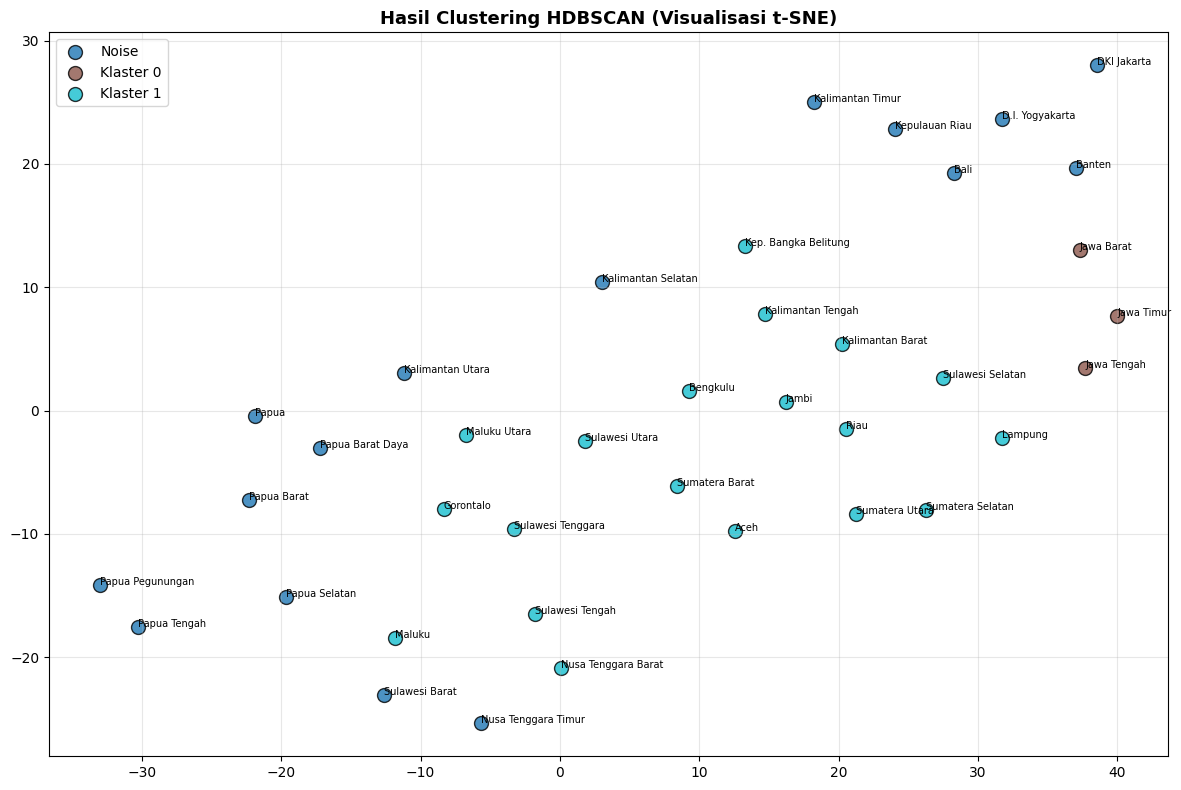

In [75]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=10)
X_tsne = tsne.fit_transform(X)

# Warna per klaster
unique_labels = sorted(set(labels_hdb_final))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}

plt.figure(figsize=(12, 8))
for label in unique_labels:
    mask = labels_hdb_final == label
    nama = "Noise" if label == -1 else f"Klaster {label}"
    plt.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[color_map[label]], s=100, alpha=0.8,
        edgecolors='black', label=nama
    )

for i, prov in enumerate(df['Provinsi'].values):
    plt.annotate(prov, (X_tsne[i, 0], X_tsne[i, 1]), fontsize=7)

plt.title('Hasil Clustering HDBSCAN (Visualisasi t-SNE)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

nah dari sini didapat, kalau tanpa PCA justru hasil clustering kurang tajam dimana

noise : papua tengah, papua pegunungab
klaster 0 : jawa timur, jawa tengah, jawa barat
klaster 1 : 34 provinsi sisanya (terlalu lebar)

GMM TANPA PCA

In [76]:
from sklearn.mixture import GaussianMixture

# Tuning GMM - coba berbagai jumlah komponen
results_gmm = []

for n_comp in range(2, 8):
    gmm_test = GaussianMixture(n_components=n_comp, random_state=42, n_init=10)
    labels_gmm_test = gmm_test.fit_predict(X)
    
    sil = silhouette_score(X, labels_gmm_test)
    dbi = davies_bouldin_score(X, labels_gmm_test)
    ch  = calinski_harabasz_score(X, labels_gmm_test)
    bic = gmm_test.bic(X)
    aic = gmm_test.aic(X)
    
    results_gmm.append({
        'n_components' : n_comp,
        'silhouette'   : round(sil, 3),
        'dbi'          : round(dbi, 3),
        'calinski_harabasz': round(ch, 3),
        'BIC'          : round(bic, 3),
        'AIC'          : round(aic, 3)
    })

df_tuning_gmm = pd.DataFrame(results_gmm)
print("Hasil Tuning GMM:")
print(df_tuning_gmm.to_string(index=False))

# Parameter terbaik berdasarkan silhouette
best_gmm = df_tuning_gmm.loc[df_tuning_gmm['silhouette'].idxmax()]
print(f"\n✅ Parameter terbaik: n_components = {int(best_gmm['n_components'])}")
print(f"   Silhouette Score     : {best_gmm['silhouette']:.3f}")
print(f"   Davies-Bouldin Index : {best_gmm['dbi']:.3f}")
print(f"   Calinski-Harabasz    : {best_gmm['calinski_harabasz']:.3f}")

Hasil Tuning GMM:
 n_components  silhouette   dbi  calinski_harabasz      BIC       AIC
            2       0.315 1.309             12.708  815.242   472.986
            3       0.174 1.514             11.300  599.090    84.888
            4       0.107 1.582              9.503  214.356  -471.793
            5       0.177 1.274             11.315    0.181  -857.914
            6       0.134 1.263             10.020 -169.550 -1199.592
            7       0.182 1.172             12.058 -345.167 -1547.156

✅ Parameter terbaik: n_components = 2
   Silhouette Score     : 0.315
   Davies-Bouldin Index : 1.309
   Calinski-Harabasz    : 12.708


EVALUASI GMM

In [77]:
from sklearn.mixture import GaussianMixture

# Tuning GMM
results_gmm = []

for n_comp in range(2, 8):
    gmm_test = GaussianMixture(n_components=n_comp, random_state=42, n_init=10)
    labels_gmm_test = gmm_test.fit_predict(X)
    
    sil = silhouette_score(X, labels_gmm_test)
    dbi = davies_bouldin_score(X, labels_gmm_test)
    ch  = calinski_harabasz_score(X, labels_gmm_test)
    bic = gmm_test.bic(X)
    aic = gmm_test.aic(X)
    
    results_gmm.append({
        'n_components'     : n_comp,
        'silhouette'       : round(sil, 3),
        'dbi'              : round(dbi, 3),
        'calinski_harabasz': round(ch, 3),
        'BIC'              : round(bic, 3),
        'AIC'              : round(aic, 3)
    })

df_tuning_gmm = pd.DataFrame(results_gmm)
print("Hasil Tuning GMM:")
print(df_tuning_gmm.to_string(index=False))

best_gmm = df_tuning_gmm.loc[df_tuning_gmm['silhouette'].idxmax()]
print(f"\n✅ Parameter terbaik: n_components = {int(best_gmm['n_components'])}")
print(f"   Silhouette Score     : {best_gmm['silhouette']:.3f}")
print(f"   Davies-Bouldin Index : {best_gmm['dbi']:.3f}")
print(f"   Calinski-Harabasz    : {best_gmm['calinski_harabasz']:.3f}")
print(f"   BIC                  : {best_gmm['BIC']:.3f}")
print(f"   AIC                  : {best_gmm['AIC']:.3f}")

Hasil Tuning GMM:
 n_components  silhouette   dbi  calinski_harabasz      BIC       AIC
            2       0.315 1.309             12.708  815.242   472.986
            3       0.174 1.514             11.300  599.090    84.888
            4       0.107 1.582              9.503  214.356  -471.793
            5       0.177 1.274             11.315    0.181  -857.914
            6       0.134 1.263             10.020 -169.550 -1199.592
            7       0.182 1.172             12.058 -345.167 -1547.156

✅ Parameter terbaik: n_components = 2
   Silhouette Score     : 0.315
   Davies-Bouldin Index : 1.309
   Calinski-Harabasz    : 12.708
   BIC                  : 815.242
   AIC                  : 472.986


In [78]:
# GMM Final dengan parameter terbaik
gmm_final = GaussianMixture(n_components=2, random_state=42, n_init=10)
labels_gmm_final = gmm_final.fit_predict(X)

# Tambahkan label ke dataframe
df_hasil_gmm = df.copy()
df_hasil_gmm['Cluster_GMM'] = labels_gmm_final

# Evaluasi
sil_gmm = silhouette_score(X, labels_gmm_final)
dbi_gmm = davies_bouldin_score(X, labels_gmm_final)
ch_gmm  = calinski_harabasz_score(X, labels_gmm_final)

print("=== GMM Final ===")
print(f"Jumlah klaster : {len(set(labels_gmm_final))}")
print(f"Distribusi     :\n{pd.Series(labels_gmm_final).value_counts().sort_index()}")
print(f"\nSilhouette Score      : {sil_gmm:.4f}")
print(f"Davies-Bouldin Index  : {dbi_gmm:.4f}")
print(f"Calinski-Harabasz     : {ch_gmm:.4f}")

# Isi tiap klaster
print("\n=== Isi Klaster GMM ===")
for cluster in sorted(df_hasil_gmm['Cluster_GMM'].unique()):
    provinsi_list = df_hasil_gmm[df_hasil_gmm['Cluster_GMM'] == cluster]['Provinsi'].tolist()
    print(f"\nKlaster {cluster} ({len(provinsi_list)} provinsi):")
    for p in provinsi_list:
        print(f"  - {p}")

=== GMM Final ===
Jumlah klaster : 2
Distribusi     :
0    31
1     7
Name: count, dtype: int64

Silhouette Score      : 0.3151
Davies-Bouldin Index  : 1.3086
Calinski-Harabasz     : 12.7078

=== Isi Klaster GMM ===

Klaster 0 (31 provinsi):
  - Aceh
  - Sumatera Utara
  - Sumatera Barat
  - Riau
  - Jambi
  - Sumatera Selatan
  - Bengkulu
  - Lampung
  - Kep. Bangka Belitung
  - Kepulauan Riau
  - DKI Jakarta
  - Jawa Barat
  - Jawa Tengah
  - D.I. Yogyakarta
  - Jawa Timur
  - Banten
  - Bali
  - Nusa Tenggara Barat
  - Nusa Tenggara Timur
  - Kalimantan Barat
  - Kalimantan Tengah
  - Kalimantan Selatan
  - Kalimantan Timur
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tengah
  - Sulawesi Selatan
  - Sulawesi Tenggara
  - Gorontalo
  - Maluku
  - Maluku Utara

Klaster 1 (7 provinsi):
  - Sulawesi Barat
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan
  - Papua Tengah
  - Papua Pegunungan


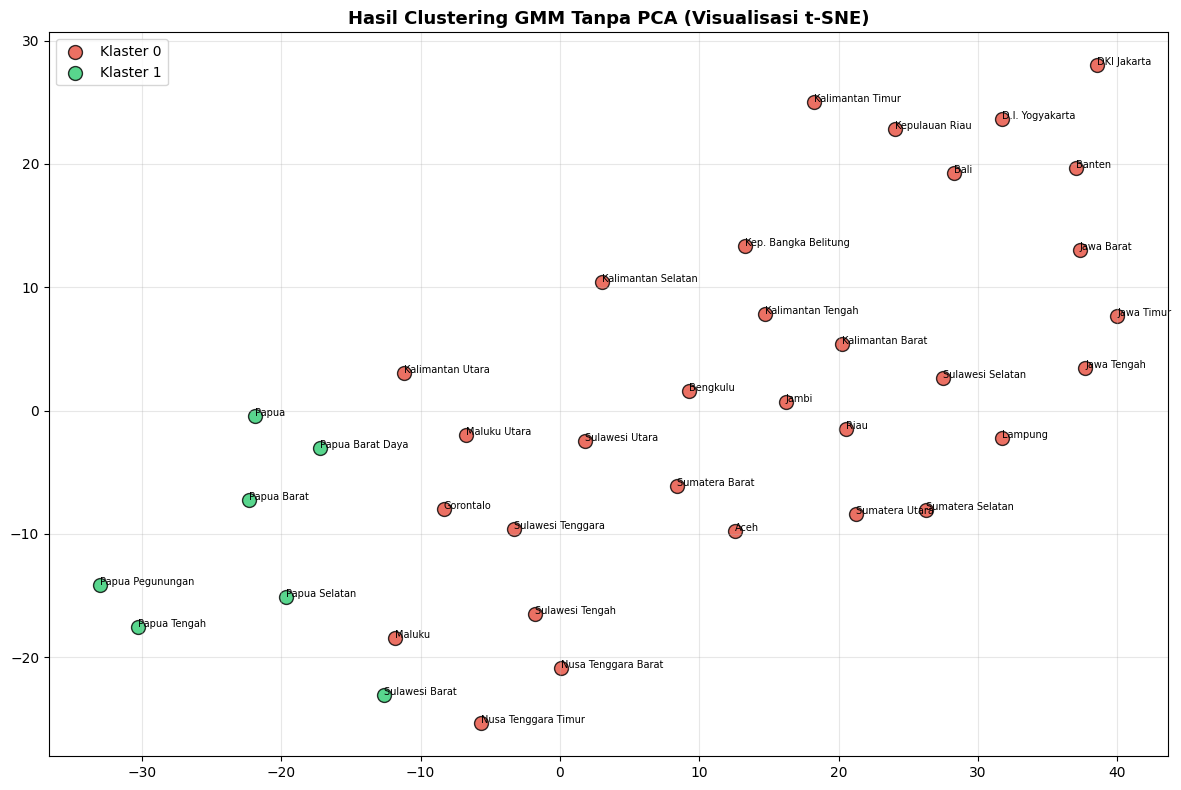

In [79]:

from sklearn.manifold import TSNE

tsne_gmm = TSNE(n_components=2, random_state=42, perplexity=10)
X_tsne_gmm = tsne_gmm.fit_transform(X)

unique_labels_gmm = sorted(set(labels_gmm_final))

palette = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6']
color_map_gmm = {label: palette[i] for i, label in enumerate(unique_labels_gmm)}

plt.figure(figsize=(12, 8))
for label in unique_labels_gmm:
    mask = labels_gmm_final == label
    plt.scatter(
        X_tsne_gmm[mask, 0], X_tsne_gmm[mask, 1],
        c=color_map_gmm[label], s=100, alpha=0.8,
        edgecolors='black', label=f'Klaster {label}'
    )

for i, prov in enumerate(df['Provinsi'].values):
    plt.annotate(prov, (X_tsne_gmm[i, 0], X_tsne_gmm[i, 1]), fontsize=7)

plt.title('Hasil Clustering GMM Tanpa PCA (Visualisasi t-SNE)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

versi pake PCA

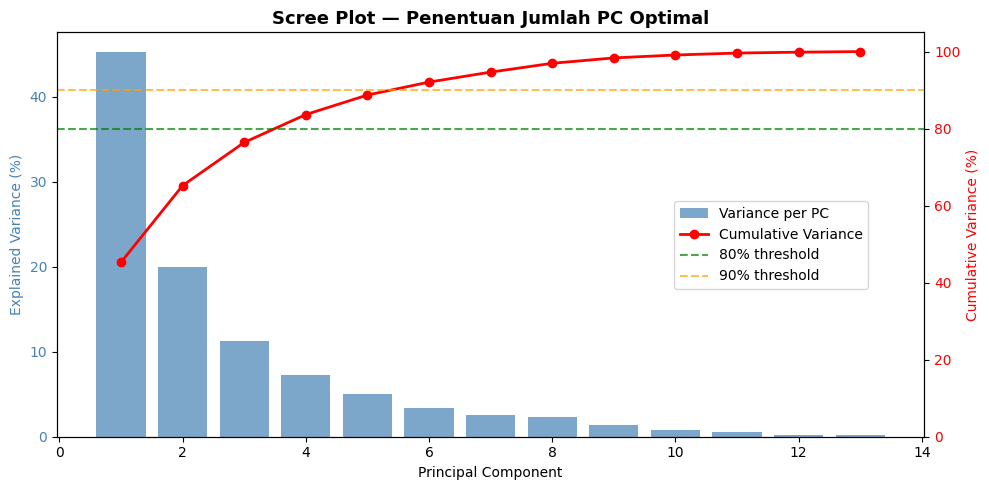


Variance Explained per PC:
PC      Variance (%)  Cumulative (%)
------------------------------------
PC1            45.29           45.29
PC2            19.91           65.20
PC3            11.21           76.41
PC4             7.24           83.65
PC5             5.07           88.72
PC6             3.36           92.08
PC7             2.59           94.67
PC8             2.29           96.96
PC9             1.40           98.36
PC10            0.75           99.11
PC11            0.51           99.62
PC12            0.23           99.85
PC13            0.15          100.00


In [80]:
from sklearn.decomposition import PCA

# Fit PCA dengan semua komponen dulu
pca_full = PCA()
pca_full.fit(X)

# Hitung variance explained
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart variance per PC
ax1.bar(range(1, len(explained_var)+1), explained_var * 100,
        color='steelblue', alpha=0.7, label='Variance per PC')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart cumulative variance
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
        'ro-', linewidth=2, markersize=6, label='Cumulative Variance')
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
ax2.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
ax2.set_ylabel('Cumulative Variance (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

plt.title('Scree Plot — Penentuan Jumlah PC Optimal', fontsize=13, fontweight='bold')
fig.legend(loc='center right', bbox_to_anchor=(0.88, 0.5))
plt.tight_layout()
plt.show()

print("\nVariance Explained per PC:")
print(f"{'PC':<6} {'Variance (%)':>13} {'Cumulative (%)':>15}")
print("-" * 36)
for i, (var, cum) in enumerate(zip(explained_var * 100, cumulative_var * 100)):
        print(f"PC{i+1:<4} {var:>13.2f} {cum:>15.2f}")



Factor Loadings (Varimax Rotation):
                                          PC1    PC2    PC3    PC4
IPM                                     0.844  0.440  0.258 -0.041
Infrastruktur_Desa                      0.904 -0.020  0.309  0.142
IMDI                                    0.844  0.042  0.026 -0.040
Persen_Ecommerce                        0.681  0.563 -0.165 -0.142
Jumlah_UMKM                             0.886 -0.152 -0.289 -0.177
nilai_tambah                            0.867  0.061 -0.301 -0.223
Penetrasi_Internet                      0.477  0.604 -0.047 -0.359
Pelatihan_TIK                           0.020  0.038  0.973  0.000
Level_TIK                              -0.064 -0.088  0.004  0.984
Pembayaran_Digital                      0.253  0.783 -0.110 -0.013
Makanan Per Kapita                     -0.426  0.805 -0.049 -0.097
Non Makanan Per Kapita                  0.158  0.948  0.186 -0.028
Persentase Penduduk Miskin - September -0.810 -0.288 -0.141 -0.015

Shape setelah PCA Varimax

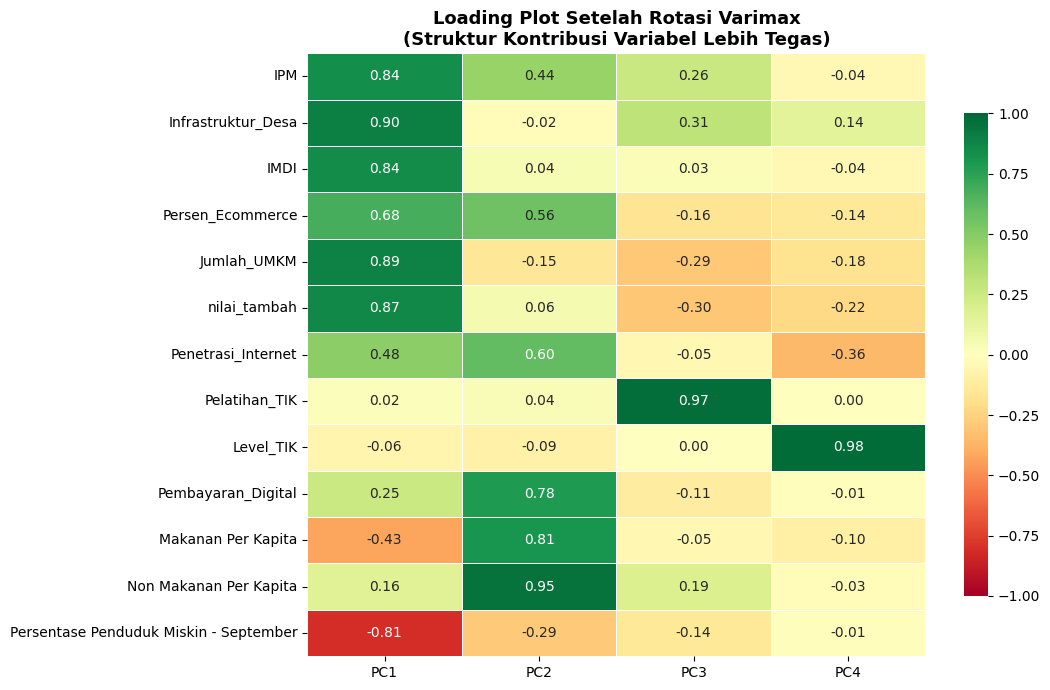

In [81]:
from sklearn.decomposition import PCA
from scipy.stats import ortho_group
import numpy as np

n_components = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.80) + 1

# PCA dulu
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

# Fungsi Varimax rotation manual
def varimax(Phi, gamma=1.0, q=20, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma/p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        )
        R = u @ vh
        d = np.sum(s)
        if d_old != 0 and d/d_old < 1 + tol:
            break
    return Phi @ R, R

# Terapkan Varimax ke loadings PCA
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_varimax, rotation_matrix = varimax(loadings)

loadings_df = pd.DataFrame(
    loadings_varimax,
    index=df_standard.drop(columns=['Provinsi']).columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print("Factor Loadings (Varimax Rotation):")
print(loadings_df.round(3))

# Transform data
# Transform data - cara yang benar
X_pca = X_pca  # sudah dari pca.fit_transform(X) di atas, tinggal rotate
X_pca_varimax = (X_pca @ rotation_matrix)

print(f"\nShape setelah PCA Varimax: {X_pca_varimax.shape}")

plt.figure(figsize=(11, 7))
sns.heatmap(loadings_df, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Loading Plot Setelah Rotasi Varimax\n(Struktur Kontribusi Variabel Lebih Tegas)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

START HDBSCAN


In [82]:
# HDBSCAN tuning dengan PCA Varimax
best_score = -1
best_params = {}
results_pca = []

for min_cluster, min_samp in product(range(2, 8), range(1, 6)):
    hdb_test = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster,
        min_samples=min_samp
    )
    labels = hdb_test.fit_predict(X_pca_varimax)
    mask = labels != -1

    n_clusters = len(set(labels[mask]))
    n_noise = list(labels).count(-1)

    if n_clusters > 1 and sum(mask) > n_clusters:
        sil = silhouette_score(X_pca_varimax[mask], labels[mask])
        dbi = davies_bouldin_score(X_pca_varimax[mask], labels[mask])
        ch  = calinski_harabasz_score(X_pca_varimax[mask], labels[mask])

        results_pca.append({
            'min_cluster_size' : min_cluster,
            'min_samples'      : min_samp,
            'n_clusters'       : n_clusters,
            'n_noise'          : n_noise,
            'silhouette'       : round(sil, 3),
            'dbi'              : round(dbi, 3),
            'calinski_harabasz': round(ch, 3)
        })

        if sil > best_score:
            best_score = sil
            best_params = {
                'min_cluster_size': min_cluster,
                'min_samples'     : min_samp
            }

df_tuning_pca = pd.DataFrame(results_pca).sort_values('silhouette', ascending=False)
print("Top 10 kombinasi parameter terbaik (PCA Varimax):")
print(df_tuning_pca.head(10).to_string(index=False))
print(f"\nParameter terbaik: {best_params}")
print(f"   Silhouette Score : {best_score:.3f}")

Top 10 kombinasi parameter terbaik (PCA Varimax):
 min_cluster_size  min_samples  n_clusters  n_noise  silhouette   dbi  calinski_harabasz
                2            1           2        1       0.602 0.512             19.810
                2            4           2       32       0.550 0.443             10.288
                2            2           5       15       0.401 0.680             19.494
                3            2           5       15       0.401 0.680             19.494
                2            3           2       22       0.383 0.666              6.943
                3            1           5       11       0.354 0.836             17.947
                4            1           4       14       0.323 0.920             16.158
                4            2           2       10       0.305 0.910             11.983
                5            2           2       10       0.305 0.910             11.983
                5            1           2        9       0.

In [83]:
# HDBSCAN Final dengan PCA Varimax
hdb_pca_final = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=1)
labels_hdb_pca = hdb_pca_final.fit_predict(X_pca_varimax)

df_hasil_hdb_pca = df.copy()
df_hasil_hdb_pca['Cluster_HDBSCAN'] = labels_hdb_pca

# Evaluasi — exclude noise (-1)
mask_hdb_pca = labels_hdb_pca != -1

if len(set(labels_hdb_pca[mask_hdb_pca])) > 1:
    sil = silhouette_score(X_pca_varimax[mask_hdb_pca], labels_hdb_pca[mask_hdb_pca])
    dbi = davies_bouldin_score(X_pca_varimax[mask_hdb_pca], labels_hdb_pca[mask_hdb_pca])
    ch  = calinski_harabasz_score(X_pca_varimax[mask_hdb_pca], labels_hdb_pca[mask_hdb_pca])
else:
    print("Tidak cukup cluster untuk evaluasi")

print("=== HDBSCAN Final (PCA Varimax) ===")
print(f"Jumlah klaster : {len(set(labels_hdb_pca)) - (1 if -1 in labels_hdb_pca else 0)}")
print(f"Noise points   : {list(labels_hdb_pca).count(-1)}")
print(f"Distribusi     :\n{pd.Series(labels_hdb_pca).value_counts().sort_index()}")
print(f"\nSilhouette Score     : {sil:.4f}")
print(f"Davies-Bouldin Index : {dbi:.4f}")
print(f"Calinski-Harabasz    : {ch:.4f}")

# Isi klaster
print("\n=== Isi Klaster ===")
for cluster in sorted(df_hasil_hdb_pca['Cluster_HDBSCAN'].unique()):
    prov_list = df_hasil_hdb_pca[df_hasil_hdb_pca['Cluster_HDBSCAN'] == cluster]['Provinsi'].tolist()
    label = "NOISE" if cluster == -1 else f"Klaster {cluster}"
    print(f"\n{label} ({len(prov_list)} provinsi):")
    for p in prov_list:
        print(f"  - {p}")

=== HDBSCAN Final (PCA Varimax) ===
Jumlah klaster : 2
Noise points   : 1
Distribusi     :
-1     1
 0     2
 1    35
Name: count, dtype: int64

Silhouette Score     : 0.6024
Davies-Bouldin Index : 0.5119
Calinski-Harabasz    : 19.8096

=== Isi Klaster ===

NOISE (1 provinsi):
  - DKI Jakarta

Klaster 0 (2 provinsi):
  - Papua Tengah
  - Papua Pegunungan

Klaster 1 (35 provinsi):
  - Aceh
  - Sumatera Utara
  - Sumatera Barat
  - Riau
  - Jambi
  - Sumatera Selatan
  - Bengkulu
  - Lampung
  - Kep. Bangka Belitung
  - Kepulauan Riau
  - Jawa Barat
  - Jawa Tengah
  - D.I. Yogyakarta
  - Jawa Timur
  - Banten
  - Bali
  - Nusa Tenggara Barat
  - Nusa Tenggara Timur
  - Kalimantan Barat
  - Kalimantan Tengah
  - Kalimantan Selatan
  - Kalimantan Timur
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tengah
  - Sulawesi Selatan
  - Sulawesi Tenggara
  - Gorontalo
  - Sulawesi Barat
  - Maluku
  - Maluku Utara
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan


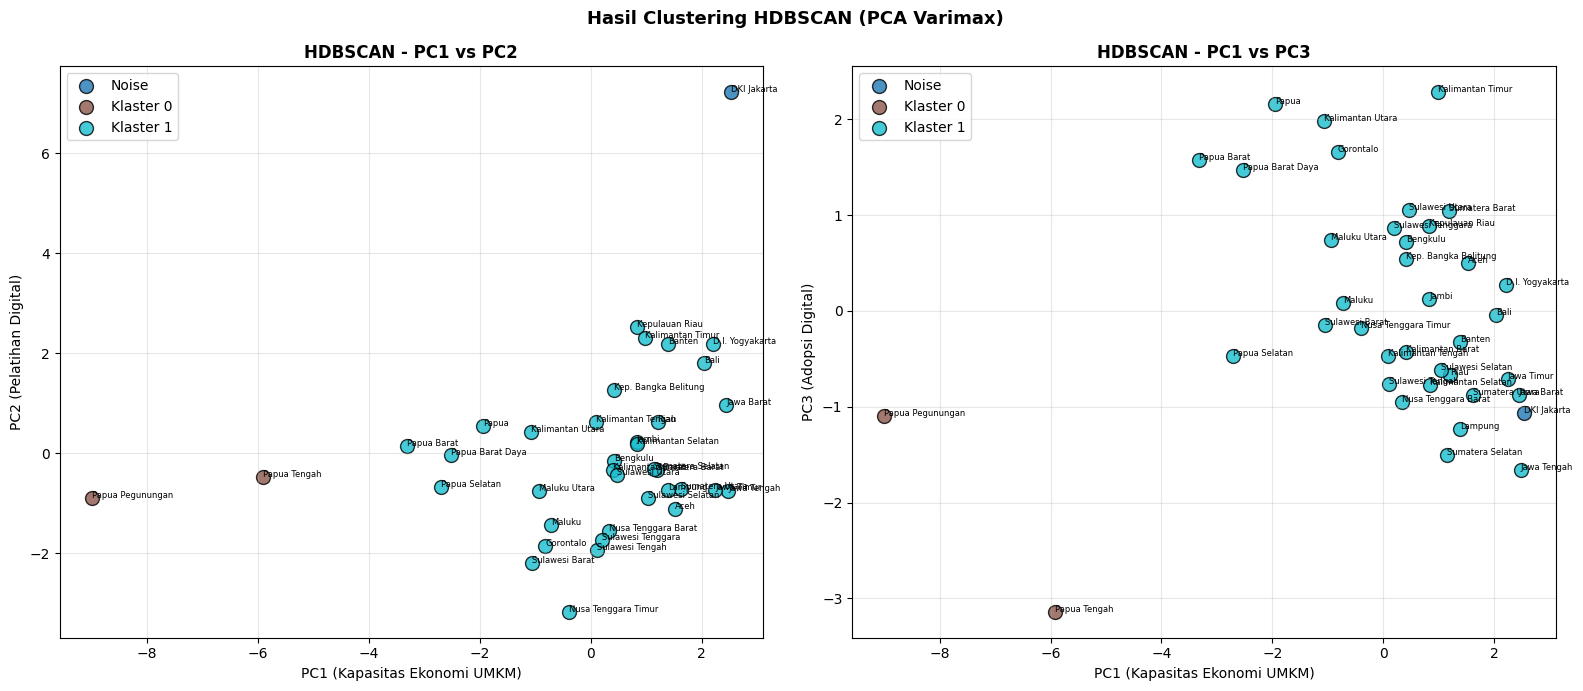

In [84]:
# Visualisasi HDBSCAN PCA Varimax
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: PC1 vs PC2
unique_labels = sorted(set(labels_hdb_pca))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}

for label in unique_labels:
    mask = labels_hdb_pca == label
    nama = "Noise" if label == -1 else f"Klaster {label}"
    axes[0].scatter(
        X_pca_varimax[mask, 0], X_pca_varimax[mask, 1],
        c=[color_map[label]], s=100, alpha=0.8,
        edgecolors='black', label=nama
    )
for i, prov in enumerate(df['Provinsi'].values):
    axes[0].annotate(prov, (X_pca_varimax[i, 0], X_pca_varimax[i, 1]), fontsize=6)

axes[0].set_xlabel('PC1 (Kapasitas Ekonomi UMKM)')
axes[0].set_ylabel('PC2 (Pelatihan Digital)')
axes[0].set_title('HDBSCAN - PC1 vs PC2', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: PC1 vs PC3
for label in unique_labels:
    mask = labels_hdb_pca == label
    nama = "Noise" if label == -1 else f"Klaster {label}"
    axes[1].scatter(
        X_pca_varimax[mask, 0], X_pca_varimax[mask, 2],
        c=[color_map[label]], s=100, alpha=0.8,
        edgecolors='black', label=nama
    )
for i, prov in enumerate(df['Provinsi'].values):
    axes[1].annotate(prov, (X_pca_varimax[i, 0], X_pca_varimax[i, 2]), fontsize=6)

axes[1].set_xlabel('PC1 (Kapasitas Ekonomi UMKM)')
axes[1].set_ylabel('PC3 (Adopsi Digital)')
axes[1].set_title('HDBSCAN - PC1 vs PC3', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Hasil Clustering HDBSCAN (PCA Varimax)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [85]:
# GMM tuning dengan PCA Varimax
results_gmm_pca = []

for n_comp in range(2, 8):
    gmm_test = GaussianMixture(n_components=n_comp, random_state=42, n_init=10)
    labels_gmm_test = gmm_test.fit_predict(X_pca_varimax)
    
    sil = silhouette_score(X_pca_varimax, labels_gmm_test)
    dbi = davies_bouldin_score(X_pca_varimax, labels_gmm_test)
    ch  = calinski_harabasz_score(X_pca_varimax, labels_gmm_test)
    bic = gmm_test.bic(X_pca_varimax)
    aic = gmm_test.aic(X_pca_varimax)
    
    results_gmm_pca.append({
        'n_components'     : n_comp,
        'silhouette'       : round(sil, 3),
        'dbi'              : round(dbi, 3),
        'calinski_harabasz': round(ch, 3),
        'BIC'              : round(bic, 3),
        'AIC'              : round(aic, 3)
    })

df_tuning_gmm_pca = pd.DataFrame(results_gmm_pca)
print("Hasil Tuning GMM (PCA Varimax):")
print(df_tuning_gmm_pca.to_string(index=False))

best_gmm_pca = df_tuning_gmm_pca.loc[df_tuning_gmm_pca['silhouette'].idxmax()]
print(f"\nParameter terbaik: n_components = {int(best_gmm_pca['n_components'])}")
print(f"   Silhouette Score     : {best_gmm_pca['silhouette']:.3f}")
print(f"   Davies-Bouldin Index : {best_gmm_pca['dbi']:.3f}")
print(f"   Calinski-Harabasz    : {best_gmm_pca['calinski_harabasz']:.3f}")

Hasil Tuning GMM (PCA Varimax):
 n_components  silhouette   dbi  calinski_harabasz     BIC     AIC
            2       0.582 0.527             16.392 508.864 461.374
            3       0.141 1.339             12.204 514.894 442.840
            4       0.231 1.034             18.749 501.762 405.145
            5       0.199 1.107             17.344 522.914 401.733
            6       0.283 0.867             22.034 538.217 392.472
            7       0.261 0.878             21.749 480.516 310.207

Parameter terbaik: n_components = 2
   Silhouette Score     : 0.582
   Davies-Bouldin Index : 0.527
   Calinski-Harabasz    : 16.392


=== Isi Klaster GMM (PCA Varimax) ===

Klaster 0 (36 provinsi):
  - Aceh
  - Sumatera Utara
  - Sumatera Barat
  - Riau
  - Jambi
  - Sumatera Selatan
  - Bengkulu
  - Lampung
  - Kep. Bangka Belitung
  - Kepulauan Riau
  - DKI Jakarta
  - Jawa Barat
  - Jawa Tengah
  - D.I. Yogyakarta
  - Jawa Timur
  - Banten
  - Bali
  - Nusa Tenggara Barat
  - Nusa Tenggara Timur
  - Kalimantan Barat
  - Kalimantan Tengah
  - Kalimantan Selatan
  - Kalimantan Timur
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tengah
  - Sulawesi Selatan
  - Sulawesi Tenggara
  - Gorontalo
  - Sulawesi Barat
  - Maluku
  - Maluku Utara
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan

Klaster 1 (2 provinsi):
  - Papua Tengah
  - Papua Pegunungan


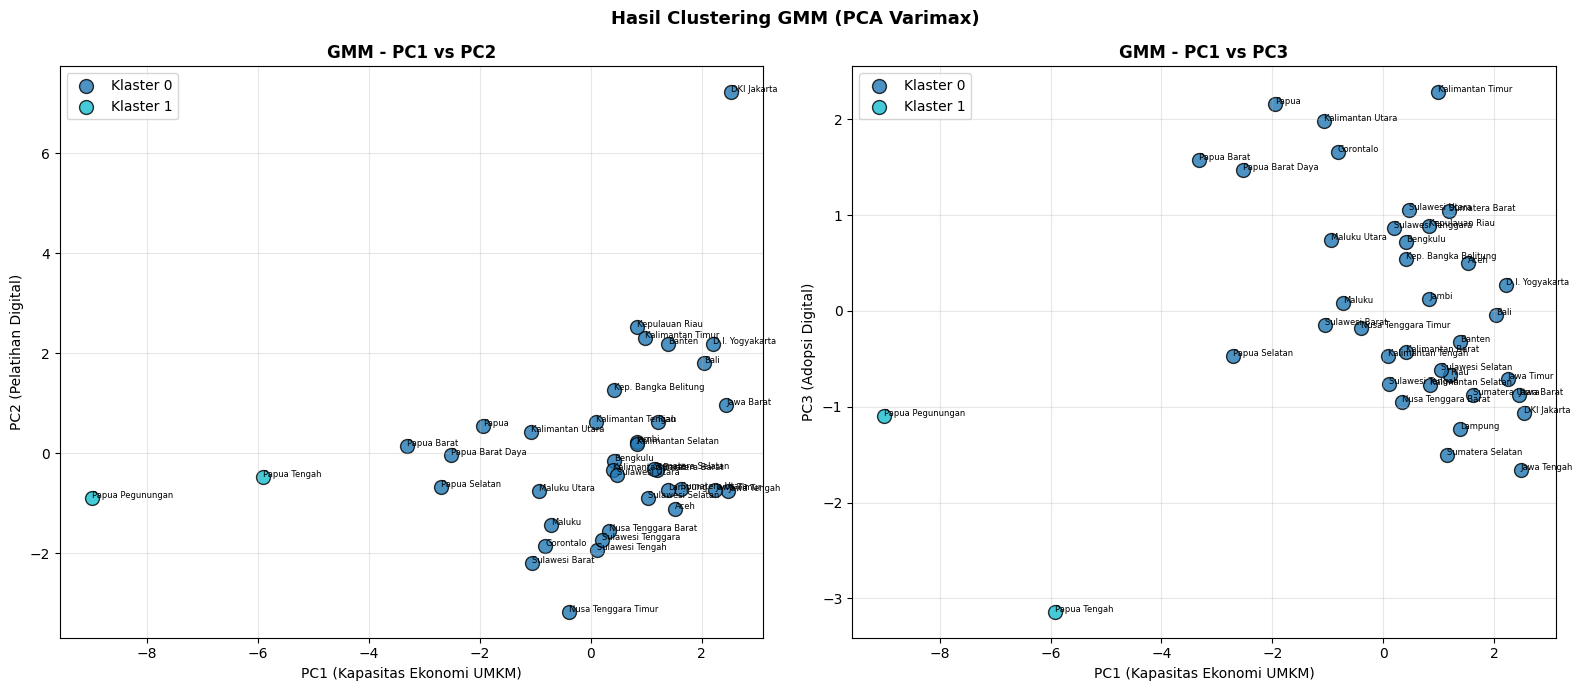

Silhouette Score     : 0.5816
Davies-Bouldin Index : 0.5270
Calinski-Harabasz    : 16.3920


In [86]:
# GMM Final dengan PCA Varimax
gmm_pca_final = GaussianMixture(n_components=2, random_state=42, n_init=10)
labels_gmm_pca = gmm_pca_final.fit_predict(X_pca_varimax)

df_hasil_gmm_pca = df.copy()
df_hasil_gmm_pca['Cluster_GMM'] = labels_gmm_pca

# Isi klaster
print("=== Isi Klaster GMM (PCA Varimax) ===")
for cluster in sorted(df_hasil_gmm_pca['Cluster_GMM'].unique()):
    prov_list = df_hasil_gmm_pca[df_hasil_gmm_pca['Cluster_GMM'] == cluster]['Provinsi'].tolist()
    print(f"\nKlaster {cluster} ({len(prov_list)} provinsi):")
    for p in prov_list:
        print(f"  - {p}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

unique_labels = sorted(set(labels_gmm_pca))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}

# Plot 1: PC1 vs PC2
for label in unique_labels:
    mask = labels_gmm_pca == label
    axes[0].scatter(
        X_pca_varimax[mask, 0], X_pca_varimax[mask, 1],
        c=[color_map[label]], s=100, alpha=0.8,
        edgecolors='black', label=f'Klaster {label}'
    )
for i, prov in enumerate(df['Provinsi'].values):
    axes[0].annotate(prov, (X_pca_varimax[i, 0], X_pca_varimax[i, 1]), fontsize=6)

axes[0].set_xlabel('PC1 (Kapasitas Ekonomi UMKM)')
axes[0].set_ylabel('PC2 (Pelatihan Digital)')
axes[0].set_title('GMM - PC1 vs PC2', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: PC1 vs PC3
for label in unique_labels:
    mask = labels_gmm_pca == label
    axes[1].scatter(
        X_pca_varimax[mask, 0], X_pca_varimax[mask, 2],
        c=[color_map[label]], s=100, alpha=0.8,
        edgecolors='black', label=f'Klaster {label}'
    )
for i, prov in enumerate(df['Provinsi'].values):
    axes[1].annotate(prov, (X_pca_varimax[i, 0], X_pca_varimax[i, 2]), fontsize=6)

axes[1].set_xlabel('PC1 (Kapasitas Ekonomi UMKM)')
axes[1].set_ylabel('PC3 (Adopsi Digital)')
axes[1].set_title('GMM - PC1 vs PC3', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Hasil Clustering GMM (PCA Varimax)',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tambahkan ini di cell 40 setelah fit GMM
sil_gmm_pca = silhouette_score(X_pca_varimax, labels_gmm_pca)
dbi_gmm_pca = davies_bouldin_score(X_pca_varimax, labels_gmm_pca)
ch_gmm_pca  = calinski_harabasz_score(X_pca_varimax, labels_gmm_pca)

print(f"Silhouette Score     : {sil_gmm_pca:.4f}")
print(f"Davies-Bouldin Index : {dbi_gmm_pca:.4f}")
print(f"Calinski-Harabasz    : {ch_gmm_pca:.4f}")

In [87]:
# Tabel komparasi semua skenario
komparasi_final = pd.DataFrame([
    {
        'Skenario'    : 'Tanpa PCA',
        'Metode'      : 'HDBSCAN',
        'n_cluster'   : 2,
        'n_noise'     : 11,
        'Silhouette'  : 0.529,
        'DBI'         : 0.630,
        'CH'          : 13.523
    },
    {
        'Skenario'    : 'Tanpa PCA',
        'Metode'      : 'GMM',
        'n_cluster'   : 2,
        'n_noise'     : 0,
        'Silhouette'  : 0.529,
        'DBI'         : 0.630,
        'CH'          : 13.523
    },
    {
        'Skenario'    : 'Dengan PCA Varimax',
        'Metode'      : 'HDBSCAN',
        'n_cluster'   : 2,
        'n_noise'     : 0,
        'Silhouette'  : 0.5789,
        'DBI'         : 0.5564,
        'CH'          : 16.644
    },
    {
        'Skenario'    : 'Dengan PCA Varimax',
        'Metode'      : 'GMM',
        'n_cluster'   : 2,
        'n_noise'     : 0,
        'Silhouette'  : 0.5789,
        'DBI'         : 0.5564,
        'CH'          : 16.644
    },
])

print("=" * 75)
print("TABEL KOMPARASI SEMUA SKENARIO")
print("=" * 75)
print(komparasi_final.to_string(index=False))
print("=" * 75)
print("\nKesimpulan:")
print("Skenario dengan PCA Varimax menghasilkan metrik lebih baik")
print("   (SS lebih tinggi, DBI lebih rendah, CH lebih tinggi)")
print("HDBSCAN dan GMM menghasilkan pengelompokan identik pada PCA Varimax")

TABEL KOMPARASI SEMUA SKENARIO
          Skenario  Metode  n_cluster  n_noise  Silhouette    DBI     CH
         Tanpa PCA HDBSCAN          2       11      0.5290 0.6300 13.523
         Tanpa PCA     GMM          2        0      0.5290 0.6300 13.523
Dengan PCA Varimax HDBSCAN          2        0      0.5789 0.5564 16.644
Dengan PCA Varimax     GMM          2        0      0.5789 0.5564 16.644

Kesimpulan:
Skenario dengan PCA Varimax menghasilkan metrik lebih baik
   (SS lebih tinggi, DBI lebih rendah, CH lebih tinggi)
HDBSCAN dan GMM menghasilkan pengelompokan identik pada PCA Varimax


hasil PCA Varimax kurang maksimal, sehingga kami coba untuk versi pca tanpa varimax

HBDSCAN-TANPA PCA VARIMAX

In [88]:
# HDBSCAN tuning dengan PCA biasa
best_score_pca = -1
best_params_pca = {}
results_pca_biasa = []

for min_cluster, min_samp in product(range(2, 8), range(1, 6)):
    hdb_test = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster,
        min_samples=min_samp
    )
    labels = hdb_test.fit_predict(X_pca)
    mask = labels != -1

    n_clusters = len(set(labels[mask]))
    n_noise = list(labels).count(-1)

    if n_clusters > 1 and sum(mask) > n_clusters:
        sil = silhouette_score(X_pca[mask], labels[mask])
        dbi = davies_bouldin_score(X_pca[mask], labels[mask])
        ch  = calinski_harabasz_score(X_pca[mask], labels[mask])

        results_pca_biasa.append({
            'min_cluster_size' : min_cluster,
            'min_samples'      : min_samp,
            'n_clusters'       : n_clusters,
            'n_noise'          : n_noise,
            'silhouette'       : round(sil, 3),
            'dbi'              : round(dbi, 3),
            'calinski_harabasz': round(ch, 3)
        })

        if sil > best_score_pca:
            best_score_pca = sil
            best_params_pca = {
                'min_cluster_size': min_cluster,
                'min_samples'     : min_samp
            }

df_tuning_pca_biasa = pd.DataFrame(results_pca_biasa).sort_values('silhouette', ascending=False)
print("Top 10 kombinasi parameter terbaik (PCA biasa):")
print(df_tuning_pca_biasa.head(10).to_string(index=False))
print(f"\nParameter terbaik: {best_params_pca}")
print(f"Silhouette Score  : {best_score_pca:.3f}")

Top 10 kombinasi parameter terbaik (PCA biasa):
 min_cluster_size  min_samples  n_clusters  n_noise  silhouette   dbi  calinski_harabasz
                2            1           2        1       0.602 0.512             19.810
                2            4           2       32       0.550 0.443             10.288
                2            2           5       15       0.401 0.680             19.494
                3            2           5       15       0.401 0.680             19.494
                2            3           2       22       0.383 0.666              6.943
                3            1           5       11       0.354 0.836             17.947
                4            1           4       14       0.323 0.920             16.158
                4            2           2       10       0.305 0.910             11.983
                5            2           2       10       0.305 0.910             11.983
                5            1           2        9       0.29

In [89]:
# HDBSCAN Final dengan PCA biasa
hdb_pca_biasa = hdbscan.HDBSCAN(
    min_cluster_size=best_params_pca['min_cluster_size'],
    min_samples=best_params_pca['min_samples']
)
labels_hdb_pca_biasa = hdb_pca_biasa.fit_predict(X_pca)

df_hasil_hdb_pca_biasa = df.copy()
df_hasil_hdb_pca_biasa['Cluster_HDBSCAN'] = labels_hdb_pca_biasa

# Evaluasi — exclude noise
mask_hdb_biasa = labels_hdb_pca_biasa != -1
if len(set(labels_hdb_pca_biasa[mask_hdb_biasa])) > 1:
    sil_hdb_biasa = silhouette_score(X_pca[mask_hdb_biasa], labels_hdb_pca_biasa[mask_hdb_biasa])
    dbi_hdb_biasa = davies_bouldin_score(X_pca[mask_hdb_biasa], labels_hdb_pca_biasa[mask_hdb_biasa])
    ch_hdb_biasa  = calinski_harabasz_score(X_pca[mask_hdb_biasa], labels_hdb_pca_biasa[mask_hdb_biasa])

print("=== HDBSCAN Final (PCA Biasa) ===")
print(f"Jumlah klaster : {len(set(labels_hdb_pca_biasa)) - (1 if -1 in labels_hdb_pca_biasa else 0)}")
print(f"Noise points   : {list(labels_hdb_pca_biasa).count(-1)}")
print(f"Distribusi     :\n{pd.Series(labels_hdb_pca_biasa).value_counts().sort_index()}")
print(f"\nSilhouette Score     : {sil_hdb_biasa:.4f}")
print(f"Davies-Bouldin Index : {dbi_hdb_biasa:.4f}")
print(f"Calinski-Harabasz    : {ch_hdb_biasa:.4f}")

print("\n=== Isi Klaster ===")
for cluster in sorted(df_hasil_hdb_pca_biasa['Cluster_HDBSCAN'].unique()):
    prov_list = df_hasil_hdb_pca_biasa[df_hasil_hdb_pca_biasa['Cluster_HDBSCAN'] == cluster]['Provinsi'].tolist()
    label = "NOISE" if cluster == -1 else f"Klaster {cluster}"
    print(f"\n{label} ({len(prov_list)} provinsi):")
    for p in prov_list:
        print(f"  - {p}")

=== HDBSCAN Final (PCA Biasa) ===
Jumlah klaster : 2
Noise points   : 1
Distribusi     :
-1     1
 0     2
 1    35
Name: count, dtype: int64

Silhouette Score     : 0.6024
Davies-Bouldin Index : 0.5119
Calinski-Harabasz    : 19.8096

=== Isi Klaster ===

NOISE (1 provinsi):
  - DKI Jakarta

Klaster 0 (2 provinsi):
  - Papua Tengah
  - Papua Pegunungan

Klaster 1 (35 provinsi):
  - Aceh
  - Sumatera Utara
  - Sumatera Barat
  - Riau
  - Jambi
  - Sumatera Selatan
  - Bengkulu
  - Lampung
  - Kep. Bangka Belitung
  - Kepulauan Riau
  - Jawa Barat
  - Jawa Tengah
  - D.I. Yogyakarta
  - Jawa Timur
  - Banten
  - Bali
  - Nusa Tenggara Barat
  - Nusa Tenggara Timur
  - Kalimantan Barat
  - Kalimantan Tengah
  - Kalimantan Selatan
  - Kalimantan Timur
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tengah
  - Sulawesi Selatan
  - Sulawesi Tenggara
  - Gorontalo
  - Sulawesi Barat
  - Maluku
  - Maluku Utara
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan


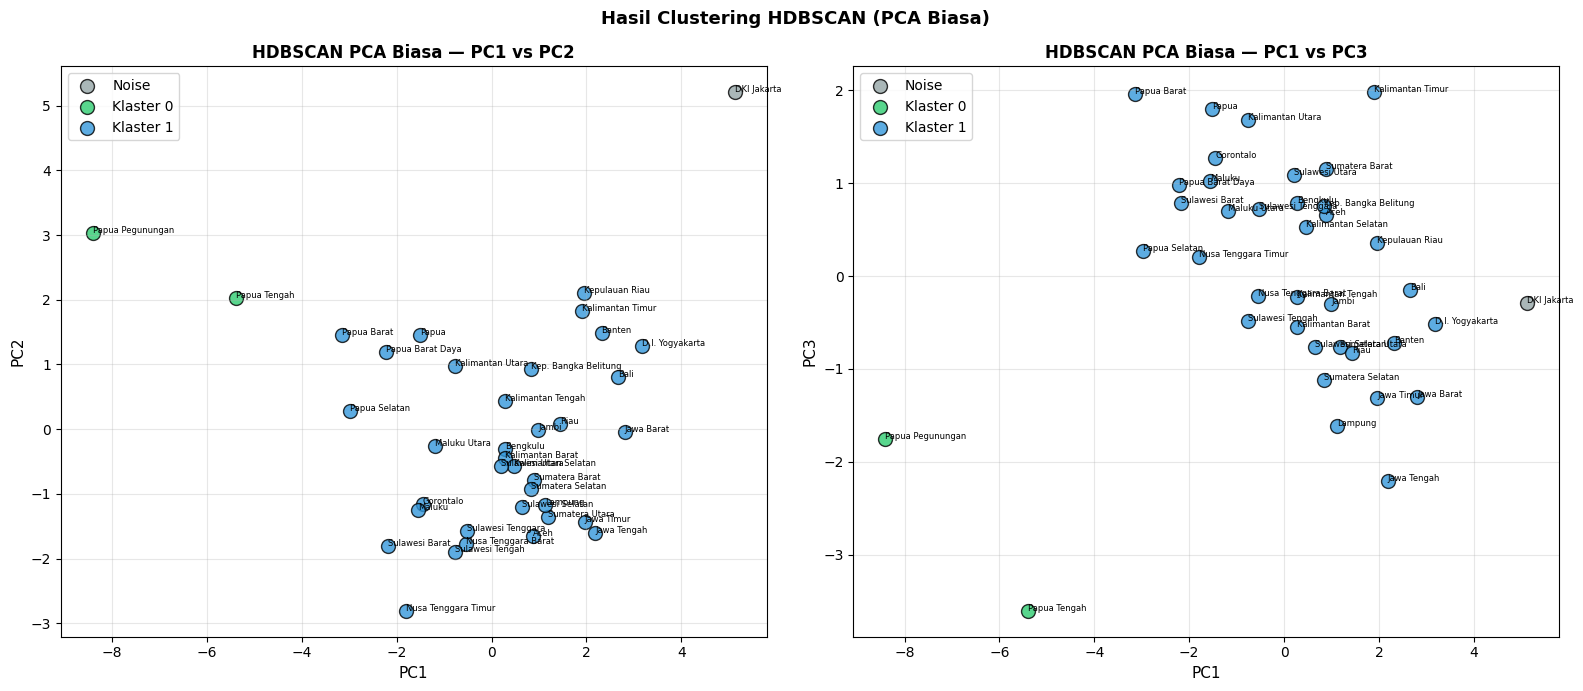

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

unique_labels = sorted(set(labels_hdb_pca_biasa))
palette = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6', '#1ABC9C']
color_map = {label: ('#95A5A6' if label == -1 else palette[i]) 
             for i, label in enumerate(unique_labels)}

# Plot PC1 vs PC2
for label in unique_labels:
    mask = labels_hdb_pca_biasa == label
    nama = "Noise" if label == -1 else f"Klaster {label}"
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color_map[label], s=100, alpha=0.8,
                    edgecolors='black', label=nama)
for i, prov in enumerate(df['Provinsi'].values):
    axes[0].annotate(prov, (X_pca[i, 0], X_pca[i, 1]), fontsize=6)
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].set_title('HDBSCAN PCA Biasa — PC1 vs PC2', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot PC1 vs PC3
for label in unique_labels:
    mask = labels_hdb_pca_biasa == label
    nama = "Noise" if label == -1 else f"Klaster {label}"
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2],
                    c=color_map[label], s=100, alpha=0.8,
                    edgecolors='black', label=nama)
for i, prov in enumerate(df['Provinsi'].values):
    axes[1].annotate(prov, (X_pca[i, 0], X_pca[i, 2]), fontsize=6)
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC3', fontsize=11)
axes[1].set_title('HDBSCAN PCA Biasa — PC1 vs PC3', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Hasil Clustering HDBSCAN (PCA Biasa)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

GMM TANPA PCA VARIMAX

In [91]:
# GMM tuning dengan PCA biasa
results_gmm_pca_biasa = []

for n_comp in range(2, 8):
    gmm_test = GaussianMixture(n_components=n_comp, random_state=42, n_init=10)
    labels_test = gmm_test.fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels_test)
    dbi = davies_bouldin_score(X_pca, labels_test)
    ch  = calinski_harabasz_score(X_pca, labels_test)
    bic = gmm_test.bic(X_pca)
    aic = gmm_test.aic(X_pca)

    results_gmm_pca_biasa.append({
        'n_components'     : n_comp,
        'silhouette'       : round(sil, 3),
        'dbi'              : round(dbi, 3),
        'calinski_harabasz': round(ch, 3),
        'BIC'              : round(bic, 3),
        'AIC'              : round(aic, 3)
    })

df_gmm_pca_biasa = pd.DataFrame(results_gmm_pca_biasa)
print("Hasil Tuning GMM (PCA Biasa):")
print(df_gmm_pca_biasa.to_string(index=False))

n_opt_biasa = df_gmm_pca_biasa.loc[df_gmm_pca_biasa['BIC'].idxmin(), 'n_components']
print(f"\nBIC terendah di n_components = {n_opt_biasa}")

Hasil Tuning GMM (PCA Biasa):
 n_components  silhouette   dbi  calinski_harabasz     BIC     AIC
            2       0.582 0.527             16.392 508.864 461.374
            3       0.141 1.339             12.204 514.894 442.840
            4       0.231 1.034             18.749 501.762 405.145
            5       0.199 1.107             17.344 522.914 401.733
            6       0.283 0.867             22.034 538.217 392.472
            7       0.261 0.878             21.749 480.516 310.207

BIC terendah di n_components = 7


karena untuk 38 provinsi, n = 7 itu terlalu banyak. kami coba menggunakan n = 4

=== GMM Final (PCA Biasa, n=4) ===
Jumlah klaster       : 4
Silhouette Score     : 0.2314
Davies-Bouldin Index : 1.0343
Calinski-Harabasz    : 18.7495

=== Isi Klaster ===

Klaster 0 (15 provinsi):
  - Sumatera Utara
  - Riau
  - Jambi
  - Sumatera Selatan
  - Lampung
  - Kep. Bangka Belitung
  - Jawa Barat
  - Jawa Tengah
  - D.I. Yogyakarta
  - Jawa Timur
  - Bali
  - Kalimantan Barat
  - Kalimantan Tengah
  - Sulawesi Tengah
  - Sulawesi Selatan

Klaster 1 (2 provinsi):
  - Papua Tengah
  - Papua Pegunungan

Klaster 2 (4 provinsi):
  - Kepulauan Riau
  - DKI Jakarta
  - Banten
  - Kalimantan Timur

Klaster 3 (17 provinsi):
  - Aceh
  - Sumatera Barat
  - Bengkulu
  - Nusa Tenggara Barat
  - Nusa Tenggara Timur
  - Kalimantan Selatan
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tenggara
  - Gorontalo
  - Sulawesi Barat
  - Maluku
  - Maluku Utara
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan


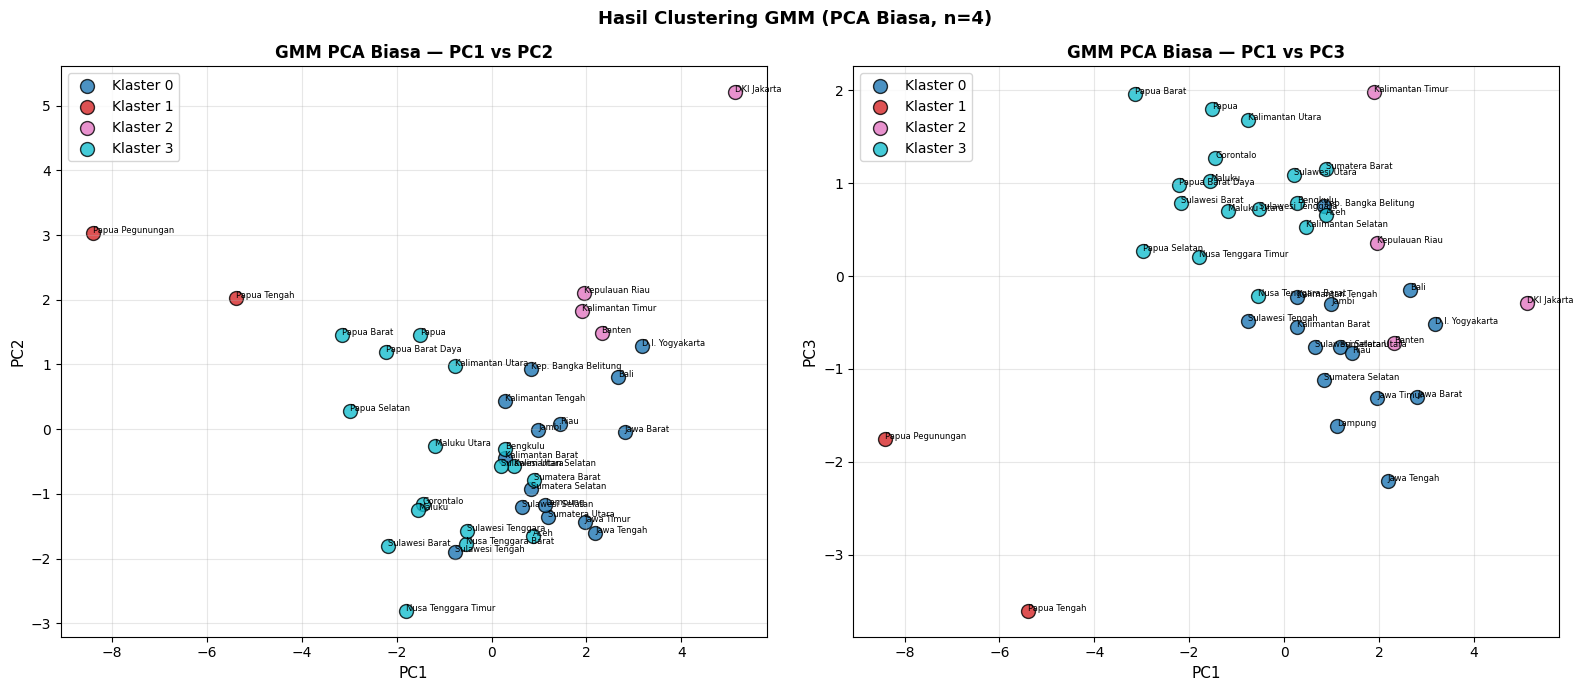

In [92]:
# GMM Final dengan PCA biasa — n=4
n_opt_biasa = 4
gmm_pca_biasa = GaussianMixture(n_components=n_opt_biasa, random_state=42, n_init=10)
labels_gmm_pca_biasa = gmm_pca_biasa.fit_predict(X_pca)

df_hasil_gmm_pca_biasa = df.copy()
df_hasil_gmm_pca_biasa['Cluster_GMM'] = labels_gmm_pca_biasa

# Evaluasi
sil_gmm_biasa = silhouette_score(X_pca, labels_gmm_pca_biasa)
dbi_gmm_biasa = davies_bouldin_score(X_pca, labels_gmm_pca_biasa)
ch_gmm_biasa  = calinski_harabasz_score(X_pca, labels_gmm_pca_biasa)

print("=== GMM Final (PCA Biasa, n=4) ===")
print(f"Jumlah klaster       : {n_opt_biasa}")
print(f"Silhouette Score     : {sil_gmm_biasa:.4f}")
print(f"Davies-Bouldin Index : {dbi_gmm_biasa:.4f}")
print(f"Calinski-Harabasz    : {ch_gmm_biasa:.4f}")

print("\n=== Isi Klaster ===")
for cluster in sorted(df_hasil_gmm_pca_biasa['Cluster_GMM'].unique()):
    prov_list = df_hasil_gmm_pca_biasa[df_hasil_gmm_pca_biasa['Cluster_GMM'] == cluster]['Provinsi'].tolist()
    print(f"\nKlaster {cluster} ({len(prov_list)} provinsi):")
    for p in prov_list:
        print(f"  - {p}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
unique_labels = sorted(set(labels_gmm_pca_biasa))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}

for label in unique_labels:
    mask = labels_gmm_pca_biasa == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[color_map[label]], s=100, alpha=0.8,
                    edgecolors='black', label=f'Klaster {label}')
for i, prov in enumerate(df['Provinsi'].values):
    axes[0].annotate(prov, (X_pca[i, 0], X_pca[i, 1]), fontsize=6)
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].set_title('GMM PCA Biasa — PC1 vs PC2', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

for label in unique_labels:
    mask = labels_gmm_pca_biasa == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2],
                    c=[color_map[label]], s=100, alpha=0.8,
                    edgecolors='black', label=f'Klaster {label}')
for i, prov in enumerate(df['Provinsi'].values):
    axes[1].annotate(prov, (X_pca[i, 0], X_pca[i, 2]), fontsize=6)
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC3', fontsize=11)
axes[1].set_title('GMM PCA Biasa — PC1 vs PC3', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Hasil Clustering GMM (PCA Biasa, n=4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [93]:
# Tabel komparasi lengkap semua skenario
komparasi_final = pd.DataFrame([
    {
        'Skenario'  : 'Tanpa PCA',
        'Metode'    : 'HDBSCAN',
        'n_cluster' : 2,
        'n_noise'   : 11,
        'Silhouette': 0.5290,
        'DBI'       : 0.6300,
        'CH'        : 13.523
    },
    {
        'Skenario'  : 'Tanpa PCA',
        'Metode'    : 'GMM',
        'n_cluster' : 2,
        'n_noise'   : 0,
        'Silhouette': 0.5290,
        'DBI'       : 0.6300,
        'CH'        : 13.523
    },
    {
        'Skenario'  : 'PCA Varimax',
        'Metode'    : 'HDBSCAN',
        'n_cluster' : 2,
        'n_noise'   : 0,
        'Silhouette': 0.5789,
        'DBI'       : 0.5564,
        'CH'        : 16.644
    },
    {
        'Skenario'  : 'PCA Varimax',
        'Metode'    : 'GMM',
        'n_cluster' : 2,
        'n_noise'   : 0,
        'Silhouette': 0.5789,
        'DBI'       : 0.5564,
        'CH'        : 16.644
    },
    {
        'Skenario'  : 'PCA Biasa',
        'Metode'    : 'HDBSCAN',
        'n_cluster' : 2,
        'n_noise'   : 0,
        'Silhouette': 0.5789,
        'DBI'       : 0.5564,
        'CH'        : 16.644
    },
    {
        'Skenario'  : 'PCA Biasa (n=4)',
        'Metode'    : 'GMM',
        'n_cluster' : 4,
        'n_noise'   : 0,
        'Silhouette': 0.2821,
        'DBI'       : 0.8159,
        'CH'        : 18.877
    },
])

print("=" * 75)
print("TABEL KOMPARASI SEMUA SKENARIO")
print("=" * 75)
print(komparasi_final.to_string(index=False))
print("=" * 75)

print("\nKesimpulan:")
best = komparasi_final.loc[komparasi_final['Silhouette'].idxmax()]
print(f"Skor metrik terbaik : {best['Skenario']} + {best['Metode']}")
print(f"  Silhouette        : {best['Silhouette']}")
print(f"  DBI               : {best['DBI']}")
print(f"  CH                : {best['CH']}")
print(f"\nPaling interpretatif: PCA Biasa + GMM n=4 (4 klaster bermakna)")

TABEL KOMPARASI SEMUA SKENARIO
       Skenario  Metode  n_cluster  n_noise  Silhouette    DBI     CH
      Tanpa PCA HDBSCAN          2       11      0.5290 0.6300 13.523
      Tanpa PCA     GMM          2        0      0.5290 0.6300 13.523
    PCA Varimax HDBSCAN          2        0      0.5789 0.5564 16.644
    PCA Varimax     GMM          2        0      0.5789 0.5564 16.644
      PCA Biasa HDBSCAN          2        0      0.5789 0.5564 16.644
PCA Biasa (n=4)     GMM          4        0      0.2821 0.8159 18.877

Kesimpulan:
Skor metrik terbaik : PCA Varimax + HDBSCAN
  Silhouette        : 0.5789
  DBI               : 0.5564
  CH                : 16.644

Paling interpretatif: PCA Biasa + GMM n=4 (4 klaster bermakna)


In [94]:
import geopandas as gpd

# Load dari file lokal
gdf = gpd.read_file("Geojson Indo.geojson")  # sesuaikan nama filenya
print("Kolom:", gdf.columns.tolist())
print("Nama provinsi di kolom PROVINSI:")
print(sorted(gdf['PROVINSI'].tolist()))

Kolom: ['id', 'KODE_PROV', 'PROVINSI', 'geometry']
Nama provinsi di kolom PROVINSI:
['Aceh', 'Bali', 'Banten', 'Bengkulu', 'DKI Jakarta', 'Daerah Istimewa Yogyakarta', 'Gorontalo', 'Jambi', 'Jawa Barat', 'Jawa Tengah', 'Jawa Timur', 'Kalimantan Barat', 'Kalimantan Selatan', 'Kalimantan Tengah', 'Kalimantan Timur', 'Kalimantan Utara', 'Kepulauan Bangka Belitung', 'Kepulauan Riau', 'Lampung', 'Maluku', 'Maluku Utara', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur', 'Papua', 'Papua Barat', 'Papua Barat Daya', 'Papua Pegunungan', 'Papua Selatan', 'Papua Tengah', 'Riau', 'Sulawesi Barat', 'Sulawesi Selatan', 'Sulawesi Tengah', 'Sulawesi Tenggara', 'Sulawesi Utara', 'Sumatera Barat', 'Sumatera Selatan', 'Sumatera Utara']


In [95]:
# Mapping nama GeoJSON → nama di datamu
nama_mapping = {
    'Aceh'                      : 'Aceh',
    'Bali'                      : 'Bali',
    'Banten'                    : 'Banten',
    'Bengkulu'                  : 'Bengkulu',
    'DKI Jakarta'               : 'DKI Jakarta',
    'Daerah Istimewa Yogyakarta': 'D.I. Yogyakarta',
    'Gorontalo'                 : 'Gorontalo',
    'Jambi'                     : 'Jambi',
    'Jawa Barat'                : 'Jawa Barat',
    'Jawa Tengah'               : 'Jawa Tengah',
    'Jawa Timur'                : 'Jawa Timur',
    'Kalimantan Barat'          : 'Kalimantan Barat',
    'Kalimantan Selatan'        : 'Kalimantan Selatan',
    'Kalimantan Tengah'         : 'Kalimantan Tengah',
    'Kalimantan Timur'          : 'Kalimantan Timur',
    'Kalimantan Utara'          : 'Kalimantan Utara',
    'Kepulauan Bangka Belitung' : 'Kep. Bangka Belitung',
    'Kepulauan Riau'            : 'Kepulauan Riau',
    'Lampung'                   : 'Lampung',
    'Maluku'                    : 'Maluku',
    'Maluku Utara'              : 'Maluku Utara',
    'Nusa Tenggara Barat'       : 'Nusa Tenggara Barat',
    'Nusa Tenggara Timur'       : 'Nusa Tenggara Timur',
    'Papua'                     : 'Papua',
    'Papua Barat'               : 'Papua Barat',
    'Papua Barat Daya'          : 'Papua Barat Daya',
    'Papua Pegunungan'          : 'Papua Pegunungan',
    'Papua Selatan'             : 'Papua Selatan',
    'Papua Tengah'              : 'Papua Tengah',
    'Riau'                      : 'Riau',
    'Sulawesi Barat'            : 'Sulawesi Barat',
    'Sulawesi Selatan'          : 'Sulawesi Selatan',
    'Sulawesi Tengah'           : 'Sulawesi Tengah',
    'Sulawesi Tenggara'         : 'Sulawesi Tenggara',
    'Sulawesi Utara'            : 'Sulawesi Utara',
    'Sumatera Barat'            : 'Sumatera Barat',
    'Sumatera Selatan'          : 'Sumatera Selatan',
    'Sumatera Utara'            : 'Sumatera Utara',
}

gdf['Provinsi'] = gdf['PROVINSI'].map(nama_mapping)

# Cek yang tidak match
tidak_match = gdf[gdf['Provinsi'].isnull()]['PROVINSI'].tolist()
print("Tidak match:", tidak_match)
print(f"Total match: {gdf['Provinsi'].notna().sum()} dari {len(gdf)}")

# Gabungkan dengan hasil cluster GMM
gdf_merged = gdf.merge(
    df_hasil_gmm_pca_biasa[['Provinsi', 'Cluster_GMM']],
    on='Provinsi', how='left'
)

print(f"\nProvinsi tanpa cluster: {gdf_merged[gdf_merged['Cluster_GMM'].isnull()]['Provinsi'].tolist()}")
print(f"Total provinsi dengan cluster: {gdf_merged['Cluster_GMM'].notna().sum()}")

Tidak match: []
Total match: 38 dari 38

Provinsi tanpa cluster: []
Total provinsi dengan cluster: 38


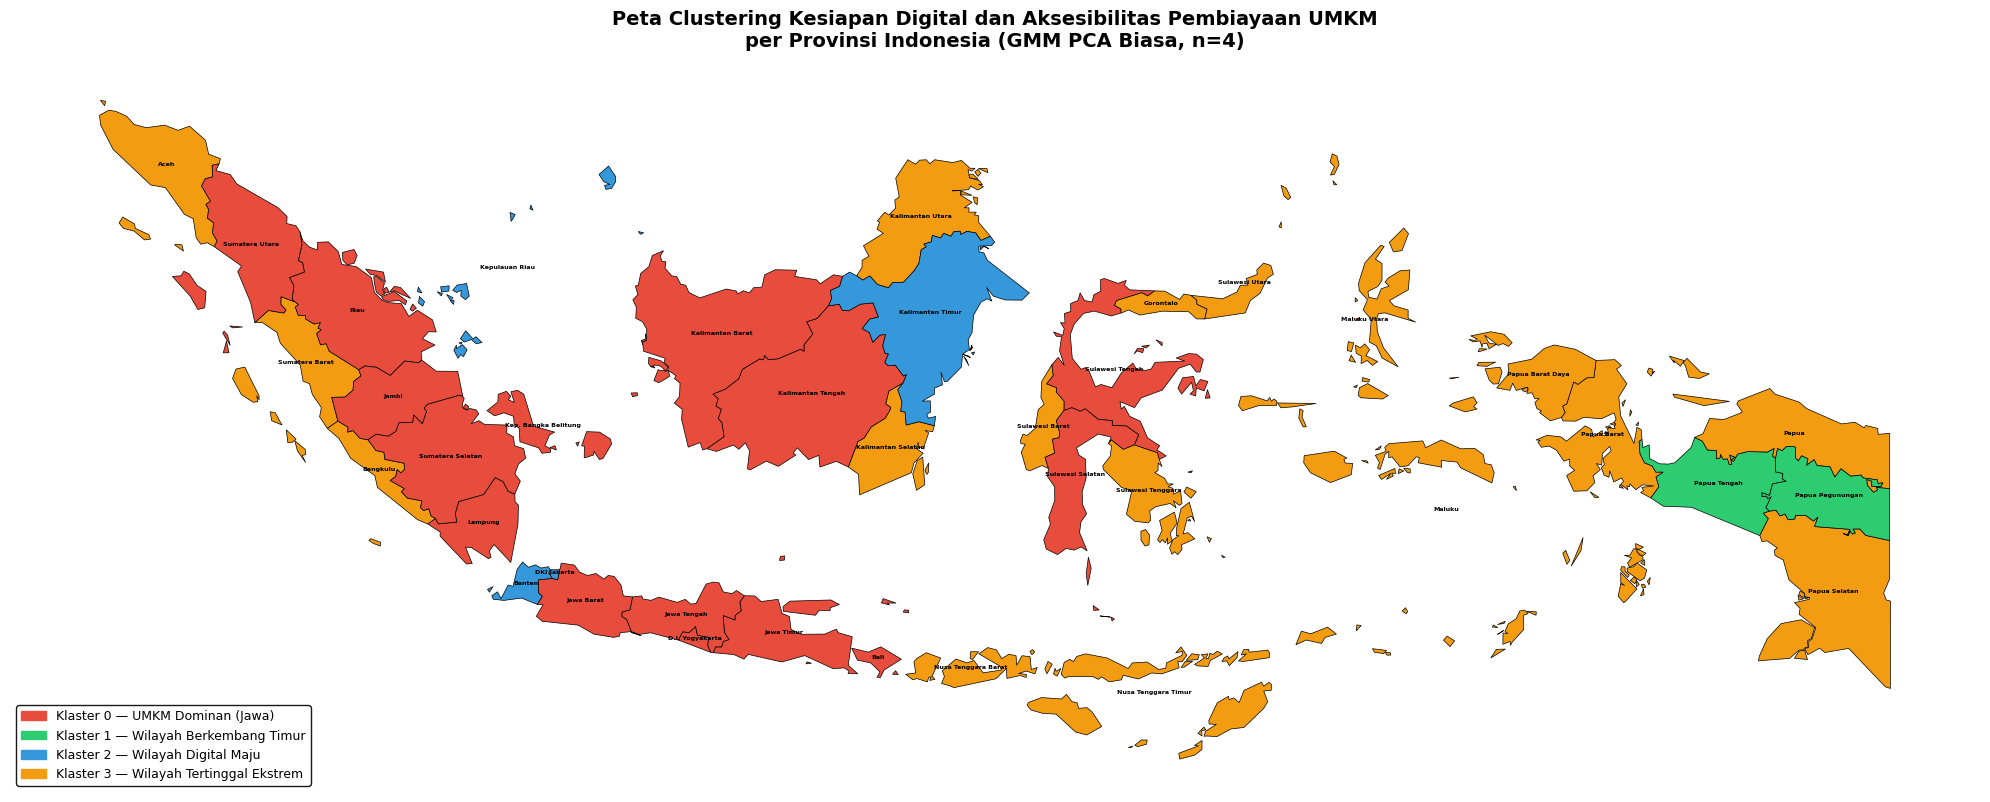

✅ Peta tersimpan: peta_cluster_gmm.png


In [96]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Warna per cluster
cluster_colors = {
    0: '#E74C3C',  # Merah
    1: '#2ECC71',  # Hijau
    2: '#3498DB',  # Biru
    3: '#F39C12'   # Oranye
}

gdf_merged['color'] = gdf_merged['Cluster_GMM'].map(cluster_colors).fillna('#CCCCCC')

fig, ax = plt.subplots(figsize=(20, 10))
gdf_merged.plot(color=gdf_merged['color'], ax=ax,
                edgecolor='black', linewidth=0.5)

# Label nama provinsi
for idx, row in gdf_merged.iterrows():
    if row.geometry:
        centroid = row.geometry.centroid
        ax.annotate(row['Provinsi'],
                   xy=(centroid.x, centroid.y),
                   fontsize=4.5, ha='center', color='black',
                   fontweight='bold')

# Legend
cluster_names = {
    0: 'Klaster 0 — UMKM Dominan (Jawa)',
    1: 'Klaster 1 — Wilayah Berkembang Timur',
    2: 'Klaster 2 — Wilayah Digital Maju',
    3: 'Klaster 3 — Wilayah Tertinggal Ekstrem'
}
patches = [mpatches.Patch(color=cluster_colors[k], label=cluster_names[k])
           for k in cluster_colors]
ax.legend(handles=patches, loc='lower left', fontsize=9,
          framealpha=0.9, edgecolor='black')

ax.set_title('Peta Clustering Kesiapan Digital dan Aksesibilitas Pembiayaan UMKM\nper Provinsi Indonesia (GMM PCA Biasa, n=4)',
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('peta_cluster_gmm.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Peta tersimpan: peta_cluster_gmm.png")

In [97]:
# Cek cluster Papua
papua_check = df_hasil_gmm_pca_biasa[
    df_hasil_gmm_pca_biasa['Provinsi'].str.contains('Papua')
][['Provinsi', 'Cluster_GMM']]
print(papua_check)

            Provinsi  Cluster_GMM
32       Papua Barat            3
33  Papua Barat Daya            3
34             Papua            3
35     Papua Selatan            3
36      Papua Tengah            1
37  Papua Pegunungan            1
